# PM2.5 Multi-Horizon Forecasting with LSTM and GRU

7-, 14-, and 30-day **forecast horizons**.

The key distinction is:
- **Input window (look-back):** fixed at 7 days.
- **Forecast horizons:** 7, 14, and 30 days ahead.
- For each forecast origin, the model sees only the previous 7 days and predicts PM2.5 at the requested future horizon.


# Interpretation

This  notebook  answers the intended question:

> **How do LSTM and GRU perform when the forecast horizon is 7, 14, or 30 days ahead, using the same 7-day historical input window?**

So:
- **7/14/30 = forecast horizons**
- **7 = fixed historical input window**
- each horizon has its own target date and its own tuned LSTM/GRU model
- the mean-collapse plot is aligned to the forecast horizon rather than the input-window length

## 1. Imports and Reproducibility

This section imports all necessary libraries for data manipulation, modeling, and visualization. It also sets a random seed to ensure reproducibility of the experiments.

In [3]:
# ============================================================
# 1. IMPORTS AND REPRODUCIBILITY
# ============================================================
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Configuration Parameters

Here, key parameters for the experiment are defined, including file paths, target variable, input window size, forecast horizons, train/validation ratios, and hyperparameter tuning ranges. These parameters govern the data loading, splitting, and model training processes.

In [4]:
# ============================================================
# 2. CONFIGURATION
# ============================================================
FILE_PATH = "/content/marylebone_train.csv"
TARGET = "pm25"

INPUT_WINDOW = 7
HORIZONS = [7, 14, 30]

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

MAX_EPOCHS = 100
PATIENCE = 10

PARAM_GRID = {
    "units": [32, 64],
    "dropout": [0.1, 0.2],
    "batch_size": [16, 32],
    "learning_rate": [0.001, 0.0005]
}

MAX_CONFIGS = None

print("Fixed input window:", INPUT_WINDOW, "days")
print("Forecast horizons:", HORIZONS, "days")

Fixed input window: 7 days
Forecast horizons: [7, 14, 30] days


## 3. Load and Clean Data

This section loads the PM2.5 dataset, converts the 'date' column to datetime objects, sorts the data chronologically, and handles any missing target values by filling them (forward and backward fill). It also identifies the numeric columns for later processing.

In [5]:
# ============================================================
# 3. LOAD AND CLEAN DATA
# ============================================================
df = pd.read_csv(FILE_PATH)

if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)

if TARGET not in df.columns:
    possible = [c for c in df.columns if c.lower() in ["pm2.5", "pm25", "pm_25"]]
    if possible:
        TARGET = possible[0]
    else:
        raise ValueError(
            f"Could not find '{TARGET}'. Available columns: {df.columns.tolist()}"
        )

df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
df[numeric_cols] = df[numeric_cols].ffill().bfill()
df = df.dropna(subset=[TARGET]).reset_index(drop=True)

print("Dataset shape:", df.shape)
print("Target:", TARGET)
print("Date range:", df["date"].min(), "to", df["date"].max())
display(df.head())

Dataset shape: (1000, 42)
Target: pm25
Date range: 2022-04-07 00:00:00 to 2024-12-31 00:00:00


,date,year,month,day_of_month,day_of_week_x,day_of_year,week_of_year,quarter,is_weekend,is_weekday,...,air_pressure_max_hpa,air_pressure_min_hpa,temperature_max_c,temperature_min_c,temperature_avg_c,mean_wind_speed_knots,wind_speed_max_knots,wind_speed_min_knots,wind_direction_deg,pm25
0,2022-04-07,2022,4,7,3,97,14,2,0,1,...,1000.9,983.9,13.59414,6.81972,10.206930,13.000000,16.0,4.0,270.636089,5.53
1,2022-04-08,2022,4,8,4,98,14,2,0,1,...,1008.6,997.8,11.35049,1.85771,6.604100,4.291667,9.0,1.0,16.779591,6.72
2,2022-04-09,2022,4,9,5,99,14,2,1,0,...,1019.1,1009.7,12.38106,0.59361,6.487335,5.458333,9.0,3.0,306.186614,5.62
3,2022-04-10,2022,4,10,6,100,14,2,1,0,...,1020.3,1016.2,13.33323,-0.20325,6.564990,2.916667,5.0,1.0,160.738319,8.36
4,2022-04-11,2022,4,11,0,101,15,2,0,1,...,1015.9,1005.9,17.46319,5.01811,11.240650,3.500000,7.0,1.0,119.167789,15.90


## 4. Chronological Train / Validation / Test Split

The dataset is split chronologically into training, validation, and testing sets based on predefined ratios. This ensures that the models are trained on past data and evaluated on future unseen data, maintaining the time series integrity.

In [6]:
# ============================================================
# 4. CHRONOLOGICAL TRAIN / VALIDATION / TEST SPLIT
# ============================================================
n = len(df)
train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

print("TRAIN:")
print(df.iloc[0]["date"], "to", df.iloc[train_end - 1]["date"])

print("\nVALIDATION:")
print(df.iloc[train_end]["date"], "to", df.iloc[val_end - 1]["date"])

print("\nTEST:")
print(df.iloc[val_end]["date"], "to", df.iloc[-1]["date"])

TRAIN:
2022-04-07 00:00:00 to 2024-03-06 00:00:00

VALIDATION:
2024-03-07 00:00:00 to 2024-08-03 00:00:00

TEST:
2024-08-04 00:00:00 to 2024-12-31 00:00:00


## 5. Scale Features and Target

Features and the target variable (`pm25`) are scaled using `MinMaxScaler`. This is crucial for neural networks like LSTMs and GRUs, as it helps in faster convergence and better performance. The scalers are fitted only on the training data to prevent data leakage.

In [7]:
# ============================================================
# 5. SCALE FEATURES AND TARGET USING TRAINING DATA ONLY
# ============================================================
feature_cols = df.select_dtypes(include=np.number).columns.tolist()

if TARGET not in feature_cols:
    raise ValueError(f"Target '{TARGET}' is not numeric.")

feature_scaler = MinMaxScaler()
feature_scaler.fit(df.loc[:train_end - 1, feature_cols])

target_scaler = MinMaxScaler()
target_scaler.fit(df.loc[:train_end - 1, [TARGET]])

X_scaled = feature_scaler.transform(df[feature_cols])
y_scaled = target_scaler.transform(df[[TARGET]]).ravel()

print("Number of input features:", len(feature_cols))
print(feature_cols)

Number of input features: 41
['year', 'month', 'day_of_month', 'day_of_week_x', 'day_of_year', 'week_of_year', 'quarter', 'is_weekend', 'is_weekday', 'season_code', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'dow_sin', 'dow_cos', 'week_sin', 'week_cos', 'pm25_lag1', 'pm25_lag7', 'pm25_rollmean3', 'pm25_rollstd3', 'day_of_week_y', 'quarter_num', 'mean_relative_humidity_pct', 'relative_humidity_max_pct', 'relative_humidity_min_pct', 'total_precipitation_mm', 'precipitation_max_mm', 'precipitation_min_mm', 'mean_air_pressure_hpa', 'air_pressure_max_hpa', 'air_pressure_min_hpa', 'temperature_max_c', 'temperature_min_c', 'temperature_avg_c', 'mean_wind_speed_knots', 'wind_speed_max_knots', 'wind_speed_min_knots', 'wind_direction_deg', 'pm25']


## 6. True Multi-Horizon Sequence Creation

This section defines a function `make_horizon_sequences` to create input-output sequences for the multi-horizon forecasting task. For each forecast horizon, it constructs sequences where the input is a fixed-size historical window (7 days), and the output is the target value at the specified future horizon.

In [8]:
# ============================================================
# 6. TRUE MULTI-HORIZON SEQUENCE CREATION
# ============================================================
def make_horizon_sequences(X, y, look_back, horizon, target_start, target_end):
    X_seq, y_seq, target_indices, origins = [], [], [], []

    # origin = last observed day in the input window
    # target = origin + horizon days
    for origin in range(look_back - 1, len(X) - horizon):

        target_idx = origin + horizon

        # Keep the target inside the requested split.
        if target_start <= target_idx < target_end:
            X_seq.append(X[origin - look_back + 1 : origin + 1])
            y_seq.append(y[target_idx])
            target_indices.append(target_idx)
            origins.append(origin)

    return (
        np.asarray(X_seq),
        np.asarray(y_seq),
        np.asarray(target_indices),
        np.asarray(origins)
    )

datasets = {}

for horizon in HORIZONS:
    datasets[horizon] = {}

    for split_name, start, end in [
        ("train", 0, train_end),
        ("val", train_end, val_end),
        ("test", val_end, len(df))
    ]:
        X_seq, y_seq, idx_seq, origins = make_horizon_sequences(
            X_scaled,
            y_scaled,
            INPUT_WINDOW,
            horizon,
            start,
            end
        )

        datasets[horizon][split_name] = {
            "X": X_seq,
            "y": y_seq,
            "indices": idx_seq,
            "origins": origins
        }

        print(
            f"Horizon={horizon:2d}d | {split_name:5s} | "
            f"X={X_seq.shape} | y={y_seq.shape}"
        )

Horizon= 7d | train | X=(687, 7, 41) | y=(687,)
Horizon= 7d | val   | X=(150, 7, 41) | y=(150,)
Horizon= 7d | test  | X=(150, 7, 41) | y=(150,)
Horizon=14d | train | X=(680, 7, 41) | y=(680,)
Horizon=14d | val   | X=(150, 7, 41) | y=(150,)
Horizon=14d | test  | X=(150, 7, 41) | y=(150,)
Horizon=30d | train | X=(664, 7, 41) | y=(664,)
Horizon=30d | val   | X=(150, 7, 41) | y=(150,)
Horizon=30d | test  | X=(150, 7, 41) | y=(150,)


## 7. Verify the Forecasting Setup

This verification step ensures that the `make_horizon_sequences` function is correctly generating the sequences. It prints the actual date corresponding to the `origin` (last day of the input window) and the `target` date for the first entry in the test set for each horizon.

In [9]:
# ============================================================
# 7. VERIFY THE FORECASTING SETUP
# ============================================================
for horizon in HORIZONS:
    d = datasets[horizon]["test"]
    first_origin = d["origins"][0]
    first_target = d["indices"][0]

    print(
        f"{horizon:2d}-day horizon: "
        f"origin={df.loc[first_origin, 'date'].date()} -> "
        f"target={df.loc[first_target, 'date'].date()}"
    )

print("\nAll models use the same 7-day input window.")
print("Only the future forecast horizon changes.")

 7-day horizon: origin=2024-07-28 -> target=2024-08-04
14-day horizon: origin=2024-07-21 -> target=2024-08-04
30-day horizon: origin=2024-07-05 -> target=2024-08-04

All models use the same 7-day input window.
Only the future forecast horizon changes.


## 8. Model Builders

This section defines the architecture for the LSTM and GRU models. Both models are sequential, with multiple recurrent layers, dropout for regularization, and a dense output layer. They are compiled with the Adam optimizer and Mean Squared Error (MSE) loss function.

In [10]:
# ============================================================
# 8. MODEL BUILDERS
# ============================================================
def build_lstm(input_window, n_features, units, dropout, learning_rate):
    model = Sequential([
        Input(shape=(input_window, n_features)),
        LSTM(units, return_sequences=True),
        Dropout(dropout),
        LSTM(units),
        Dropout(dropout),
        Dense(1)
    ])
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="mse"
    )
    return model


def build_gru(input_window, n_features, units, dropout, learning_rate):
    model = Sequential([
        Input(shape=(input_window, n_features)),
        GRU(units, return_sequences=True),
        Dropout(dropout),
        GRU(units),
        Dropout(dropout),
        Dense(1)
    ])
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="mse"
    )
    return model

## 9. Hyperparameter Tuning

This section performs hyperparameter tuning for both LSTM and GRU models across all defined forecast horizons. It iterates through combinations of units, dropout rates, batch sizes, and learning rates, training each model and recording its best validation loss. Early stopping is used to prevent overfitting.

In [11]:
# ============================================================
# 9. HYPERPARAMETER TUNING
# ============================================================
import itertools

param_combinations = list(itertools.product(
    PARAM_GRID["units"],
    PARAM_GRID["dropout"],
    PARAM_GRID["batch_size"],
    PARAM_GRID["learning_rate"]
))

if MAX_CONFIGS is not None:
    param_combinations = param_combinations[:MAX_CONFIGS]

tuning_results = []
best_models = {}
best_histories = {}
best_parameters = {}

for model_type in ["LSTM", "GRU"]:
    builder = build_lstm if model_type == "LSTM" else build_gru

    for horizon in HORIZONS:
        print("\n" + "=" * 80)
        print(
            f"TUNING {model_type} | "
            f"{horizon}-DAY FORECAST HORIZON | "
            f"{INPUT_WINDOW}-DAY INPUT WINDOW"
        )
        print("=" * 80)

        X_train = datasets[horizon]["train"]["X"]
        y_train = datasets[horizon]["train"]["y"]
        X_val = datasets[horizon]["val"]["X"]
        y_val = datasets[horizon]["val"]["y"]

        best_val_loss = np.inf
        best_model = None
        best_history = None
        best_params = None

        for trial, (units, dropout, batch_size, learning_rate) in enumerate(
            param_combinations, 1
        ):
            print(
                f"Trial {trial}/{len(param_combinations)} | "
                f"units={units}, dropout={dropout}, "
                f"batch={batch_size}, lr={learning_rate}"
            )

            model = builder(
                INPUT_WINDOW,
                X_train.shape[2],
                units,
                dropout,
                learning_rate
            )

            early_stop = EarlyStopping(
                monitor="val_loss",
                patience=PATIENCE,
                restore_best_weights=True
            )

            history = model.fit(
                X_train,
                y_train,
                validation_data=(X_val, y_val),
                epochs=MAX_EPOCHS,
                batch_size=batch_size,
                callbacks=[early_stop],
                verbose=0
            )

            min_val_loss = min(history.history["val_loss"])

            tuning_results.append({
                "Model": model_type,
                "Horizon": horizon,
                "Input_Window": INPUT_WINDOW,
                "Units": units,
                "Dropout": dropout,
                "Batch_Size": batch_size,
                "Learning_Rate": learning_rate,
                "Epochs_Used": len(history.history["loss"]),
                "Best_Validation_Loss": min_val_loss
            })

            if min_val_loss < best_val_loss:
                best_val_loss = min_val_loss
                best_model = model
                best_history = history
                best_params = {
                    "units": units,
                    "dropout": dropout,
                    "batch_size": batch_size,
                    "learning_rate": learning_rate
                }

        best_models[(model_type, horizon)] = best_model
        best_histories[(model_type, horizon)] = best_history
        best_parameters[(model_type, horizon)] = best_params

        print("BEST PARAMETERS:", best_params)
        print("BEST VALIDATION LOSS:", best_val_loss)


TUNING LSTM | 7-DAY FORECAST HORIZON | 7-DAY INPUT WINDOW
Trial 1/16 | units=32, dropout=0.1, batch=16, lr=0.001
Trial 2/16 | units=32, dropout=0.1, batch=16, lr=0.0005
Trial 3/16 | units=32, dropout=0.1, batch=32, lr=0.001
Trial 4/16 | units=32, dropout=0.1, batch=32, lr=0.0005
Trial 5/16 | units=32, dropout=0.2, batch=16, lr=0.001
Trial 6/16 | units=32, dropout=0.2, batch=16, lr=0.0005
Trial 7/16 | units=32, dropout=0.2, batch=32, lr=0.001
Trial 8/16 | units=32, dropout=0.2, batch=32, lr=0.0005
Trial 9/16 | units=64, dropout=0.1, batch=16, lr=0.001
Trial 10/16 | units=64, dropout=0.1, batch=16, lr=0.0005
Trial 11/16 | units=64, dropout=0.1, batch=32, lr=0.001
Trial 12/16 | units=64, dropout=0.1, batch=32, lr=0.0005
Trial 13/16 | units=64, dropout=0.2, batch=16, lr=0.001
Trial 14/16 | units=64, dropout=0.2, batch=16, lr=0.0005
Trial 15/16 | units=64, dropout=0.2, batch=32, lr=0.001
Trial 16/16 | units=64, dropout=0.2, batch=32, lr=0.0005
BEST PARAMETERS: {'units': 32, 'dropout': 0.1,

## 10. Tuning Results Summary

After hyperparameter tuning, this section consolidates the results into a DataFrame (`tuning_df`) and identifies the best performing hyperparameters (based on the lowest validation loss) for each model type and forecast horizon. These best parameters are then used for final model evaluation.

In [12]:
# ============================================================
# 10. TUNING RESULTS
# ============================================================
tuning_df = pd.DataFrame(tuning_results)

best_tuning_rows = []

for model_type in ["LSTM", "GRU"]:
    for horizon in HORIZONS:
        subset = tuning_df[
            (tuning_df["Model"] == model_type) &
            (tuning_df["Horizon"] == horizon)
        ]
        best_tuning_rows.append(
            subset.loc[subset["Best_Validation_Loss"].idxmin()]
        )

best_tuning_df = pd.DataFrame(best_tuning_rows).reset_index(drop=True)

display(best_tuning_df)

,Model,Horizon,Input_Window,Units,Dropout,Batch_Size,Learning_Rate,Epochs_Used,Best_Validation_Loss
0,LSTM,7,7,32,0.1,16,0.0005,11,0.013431
1,LSTM,14,7,64,0.2,32,0.0005,13,0.012721
2,LSTM,30,7,32,0.1,16,0.0005,37,0.010049
3,GRU,7,7,32,0.1,32,0.0005,12,0.012191
4,GRU,14,7,32,0.2,16,0.0010,11,0.012463
5,GRU,30,7,64,0.1,16,0.0010,34,0.010382


## 11. Best Training Histories

This section visualizes the training and validation loss curves for the best-performing LSTM and GRU models for each forecast horizon. These plots help to understand the training dynamics and detect signs of overfitting or underfitting.

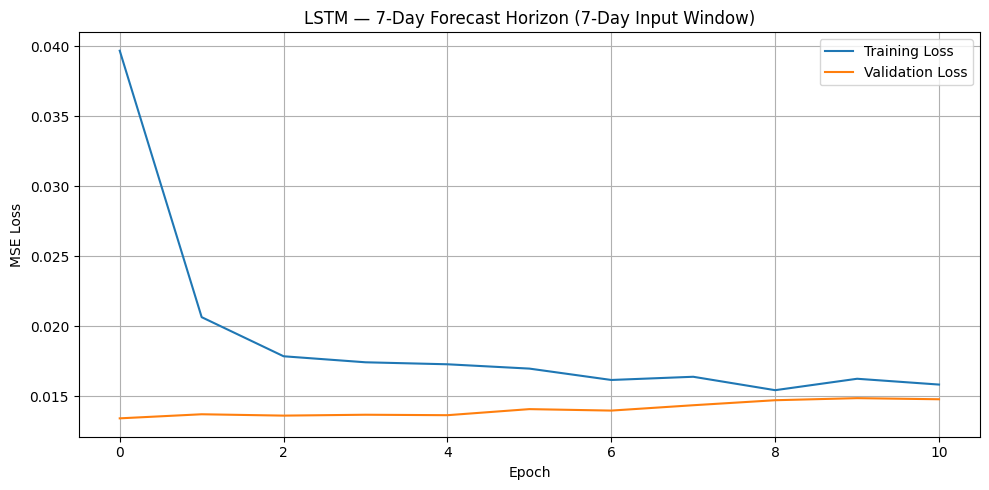

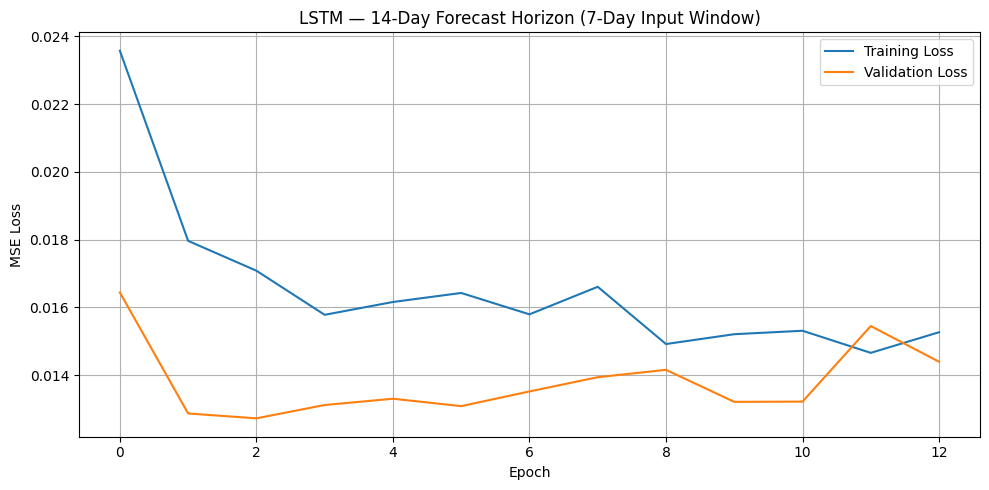

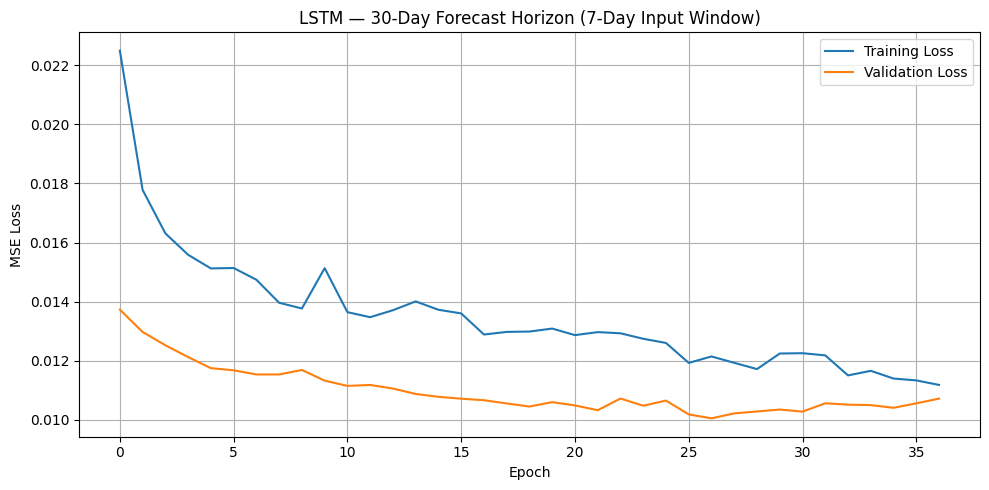

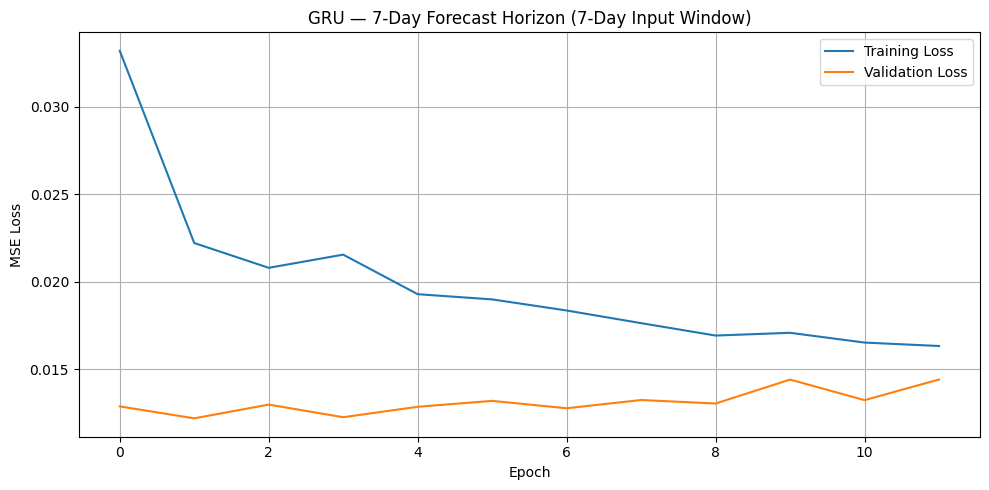

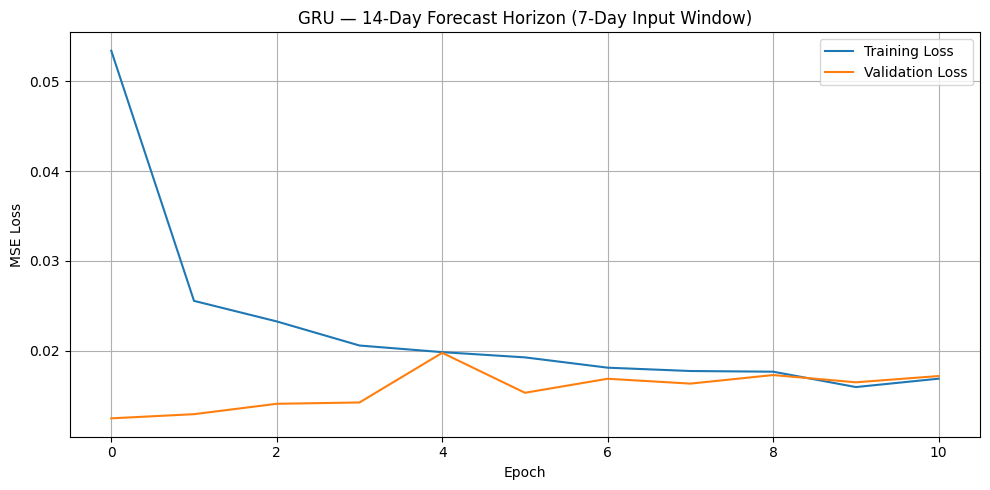

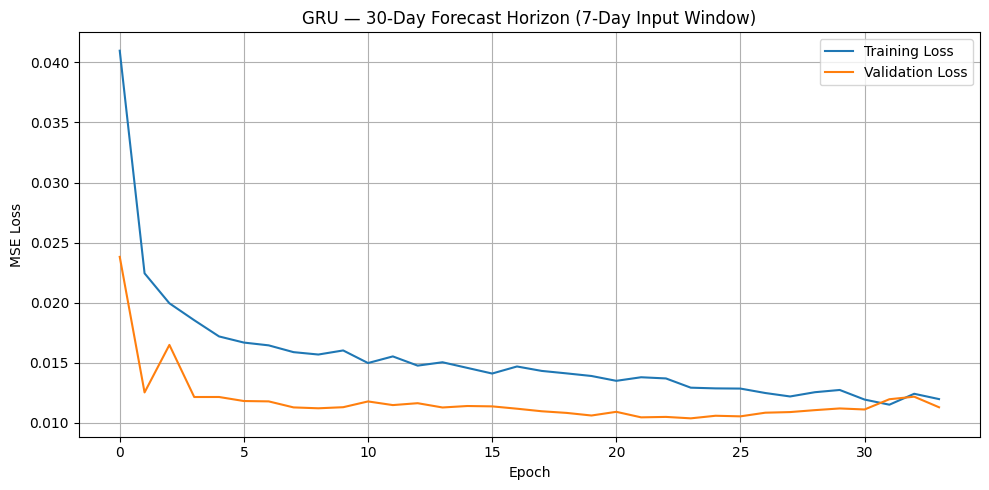

In [13]:
# ============================================================
# 11. BEST TRAINING HISTORIES
# ============================================================
for model_type in ["LSTM", "GRU"]:
    for horizon in HORIZONS:
        history = best_histories[(model_type, horizon)]

        plt.figure(figsize=(10, 5))
        plt.plot(history.history["loss"], label="Training Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")
        plt.title(
            f"{model_type} — {horizon}-Day Forecast Horizon "
            f"({INPUT_WINDOW}-Day Input Window)"
        )
        plt.xlabel("Epoch")
        plt.ylabel("MSE Loss")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

## 12. Evaluation Metrics

This section defines custom functions for various evaluation metrics: Mean Bias Error (MBE), Mean Squared Error (MSE), Mean Absolute Percentage Error (MAPE), R-squared (R²), Root Mean Squared Error (RMSE), and Mean Absolute Error (MAE). These metrics will be used to comprehensively assess model performance.

In [14]:
# ============================================================
# 12. METRICS
# ============================================================
def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    if not np.any(mask):
        return np.nan
    return np.mean(
        np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])
    ) * 100


def calculate_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    mse = mean_squared_error(y_true, y_pred)

    return {
        "MBE": np.mean(y_pred - y_true),
        "MSE": mse,
        "MAPE (%)": safe_mape(y_true, y_pred),
        "R²": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

In [15]:
# ============================================================
# 13. FINAL TEST EVALUATION — ORIGINAL PM2.5 SCALE
# ============================================================
overall_results = []
predictions = {}

for model_type in ["LSTM", "GRU"]:
    for horizon in HORIZONS:

        model = best_models[(model_type, horizon)]
        X_test = datasets[horizon]["test"]["X"]
        y_test_scaled = datasets[horizon]["test"]["y"]

        y_pred_scaled = model(
            X_test,
            training=False
        ).numpy().ravel()

        y_true = target_scaler.inverse_transform(
            y_test_scaled.reshape(-1, 1)
        ).ravel()

        y_pred = target_scaler.inverse_transform(
            y_pred_scaled.reshape(-1, 1)
        ).ravel()

        metrics = calculate_metrics(y_true, y_pred)
        metrics.update({
            "Model": model_type,
            "Horizon": horizon,
            "Input_Window": INPUT_WINDOW
        })
        overall_results.append(metrics)

        predictions[(model_type, horizon)] = {
            "y_true": y_true,
            "y_pred": y_pred,
            "indices": datasets[horizon]["test"]["indices"],
            "origins": datasets[horizon]["test"]["origins"]
        }

metrics_df = pd.DataFrame(overall_results)[
    [
        "Model", "Horizon", "Input_Window",
        "MBE", "MSE", "MAPE (%)", "R²", "RMSE", "MAE"
    ]
]

display(metrics_df.sort_values(["Horizon", "Model"]))

,Model,Horizon,Input_Window,MBE,MSE,MAPE (%),R²,RMSE,MAE
3,GRU,7,7,-2.034039,30.274974,39.151499,-0.180814,5.502270,3.553672
0,LSTM,7,7,-0.025840,26.514078,49.669703,-0.034128,5.149182,3.673634
4,GRU,14,7,-1.195250,27.994832,40.265784,-0.091881,5.291014,3.450630
1,LSTM,14,7,-1.435351,27.446317,39.775324,-0.070488,5.238923,3.406287
5,GRU,30,7,-2.029496,29.146405,35.831356,-0.136796,5.398741,3.475505
2,LSTM,30,7,-2.151899,30.717859,38.077095,-0.198087,5.542369,3.666084


## 13. Final Test Evaluation — Original PM2.5 Scale

This section evaluates the best-tuned models on the unseen test data. Predictions are made, and both actual and predicted values are inverse-transformed back to their original PM2.5 scale. The defined evaluation metrics are then calculated and stored in `metrics_df`.

## 14. Performance comparison by forecast horizon

Now the x-axis is genuinely the **forecast horizon (7, 14, 30 days)**. The input window stays fixed at 7 days.

## 14. Metric Comparison Plots

These plots visualize how different evaluation metrics (MAE, RMSE, MAPE (%), MSE, MBE, R²) change across the forecast horizons for both LSTM and GRU models. This helps in understanding the models' performance degradation or improvement as the forecast horizon increases.

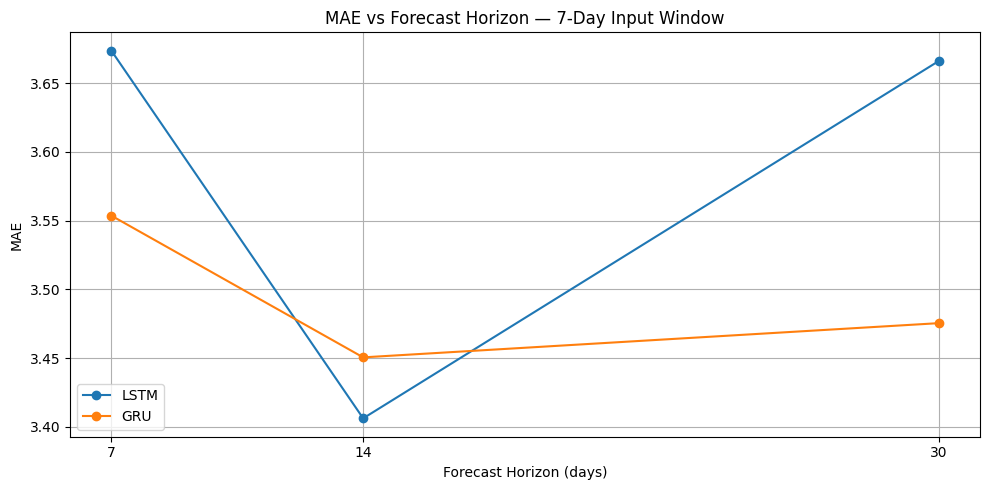

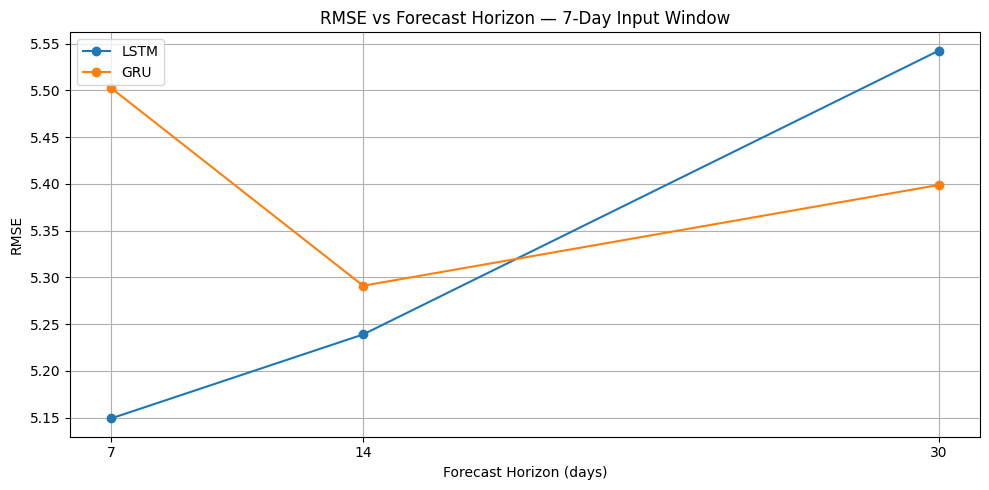

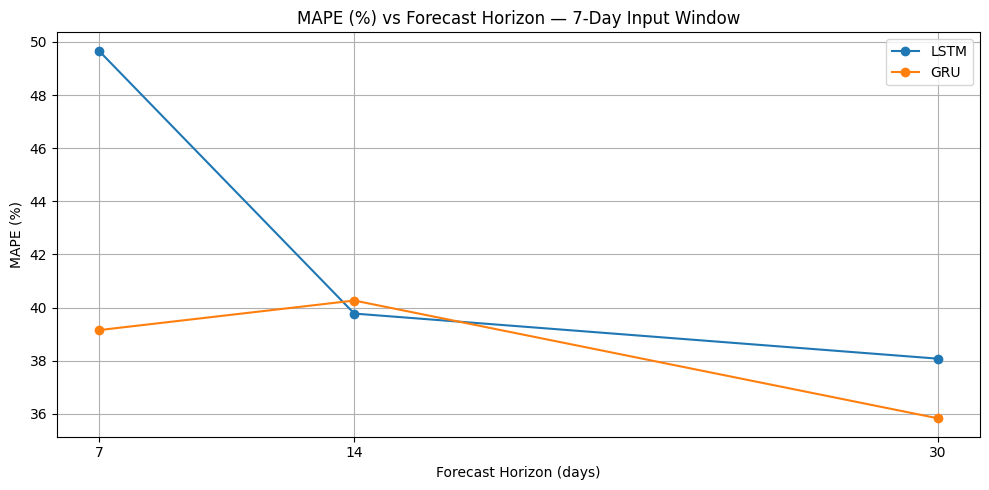

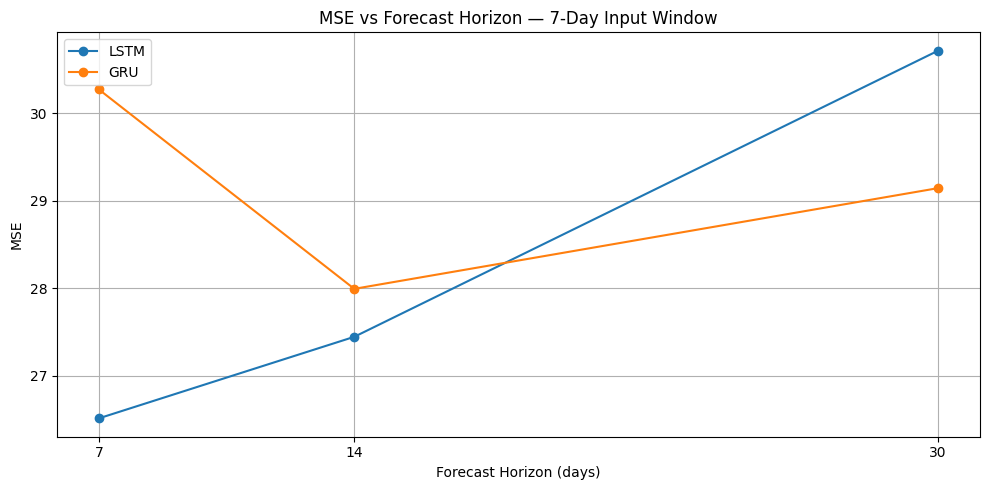

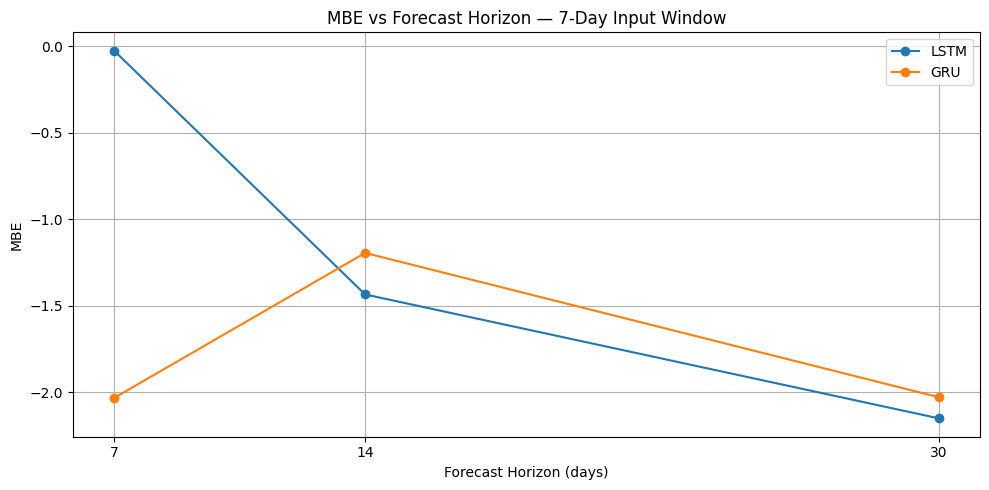

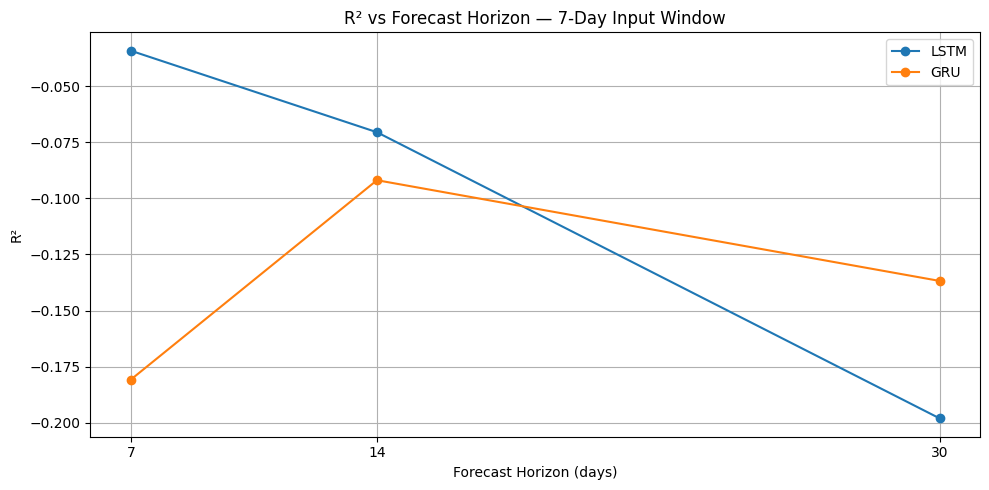

In [16]:
# ============================================================
# 14. METRIC COMPARISON PLOTS
# ============================================================
for metric in ["MAE", "RMSE", "MAPE (%)", "MSE", "MBE", "R²"]:
    plt.figure(figsize=(10, 5))

    for model_type in ["LSTM", "GRU"]:
        subset = metrics_df[
            metrics_df["Model"] == model_type
        ].sort_values("Horizon")

        plt.plot(
            subset["Horizon"],
            subset[metric],
            marker="o",
            label=model_type
        )

    plt.xlabel("Forecast Horizon (days)")
    plt.ylabel(metric)
    plt.title(f"{metric} vs Forecast Horizon — 7-Day Input Window")
    plt.xticks(HORIZONS)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

## 15. Actual vs Predicted — By Horizon

These plots show a time-series comparison of actual PM2.5 values against the predicted PM2.5 values for each model and forecast horizon. This provides a visual inspection of how well the models capture the trends and fluctuations in the data.

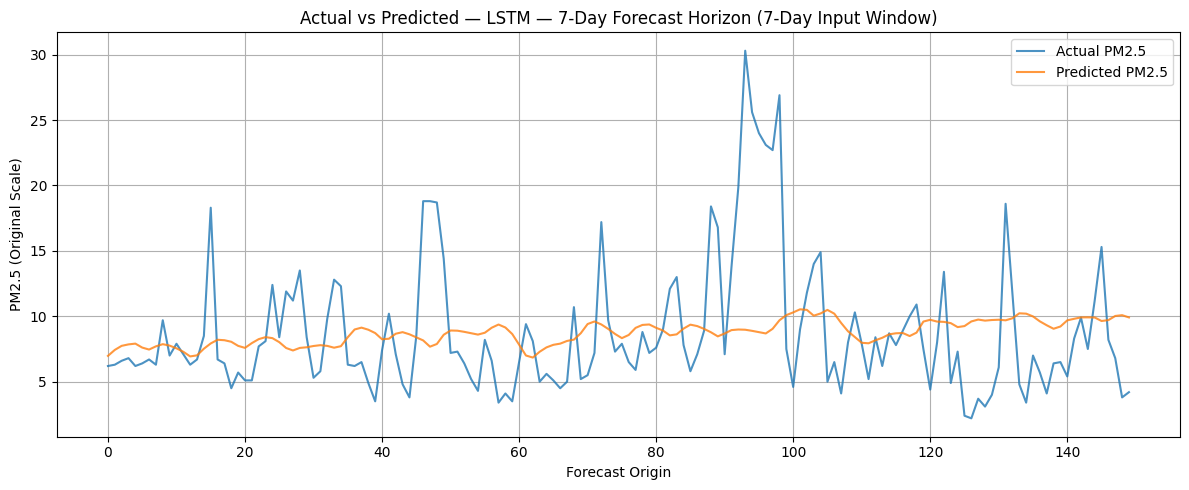

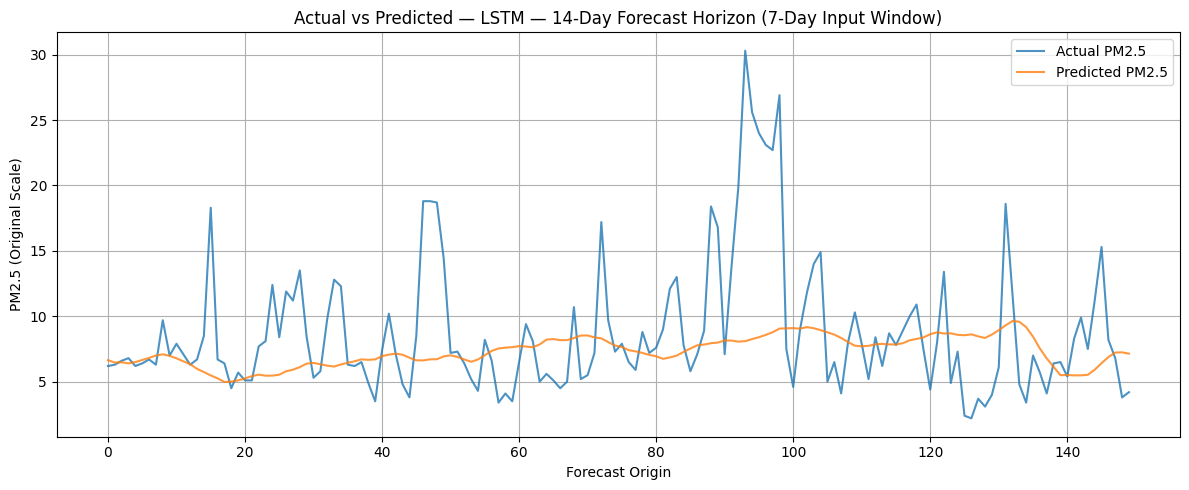

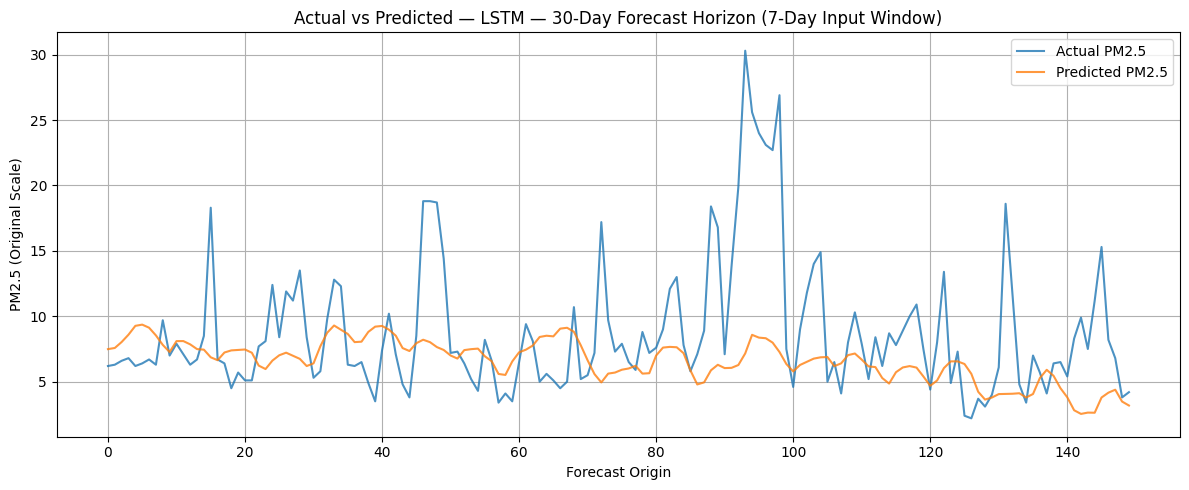

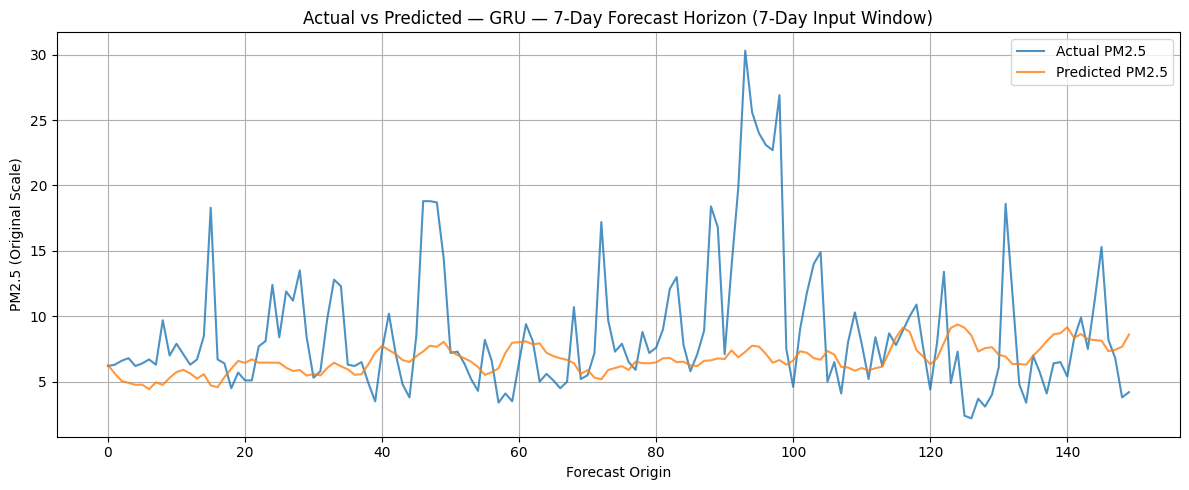

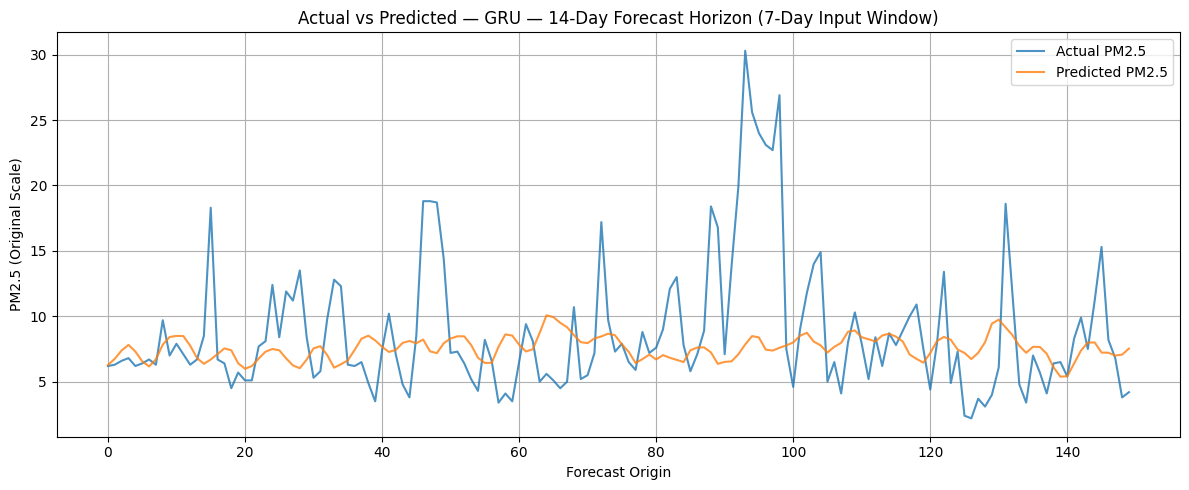

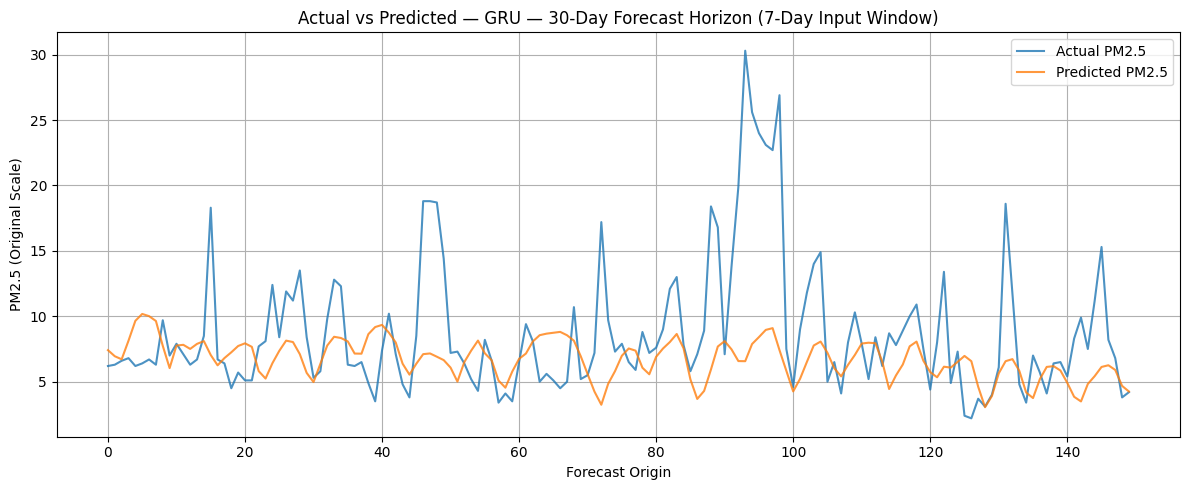

In [17]:
# ============================================================
# 15. ACTUAL VS PREDICTED — BY HORIZON
# ============================================================
for model_type in ["LSTM", "GRU"]:
    for horizon in HORIZONS:
        result = predictions[(model_type, horizon)]

        plt.figure(figsize=(12, 5))
        plt.plot(result["y_true"], label="Actual PM2.5", alpha=0.8)
        plt.plot(result["y_pred"], label="Predicted PM2.5", alpha=0.8)

        plt.title(
            f"Actual vs Predicted — {model_type} — "
            f"{horizon}-Day Forecast Horizon "
            f"(7-Day Input Window)"
        )
        plt.xlabel("Forecast Origin")
        plt.ylabel("PM2.5 (Original Scale)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

## 16. Mean Collapse Check — Horizon Forecasts

This section plots the actual vs. predicted values for each horizon alongside the mean PM2.5 values from the training and test sets. It serves as a diagnostic tool to check if the models are simply predicting the mean (mean collapse) rather than capturing the dynamics of the time series.

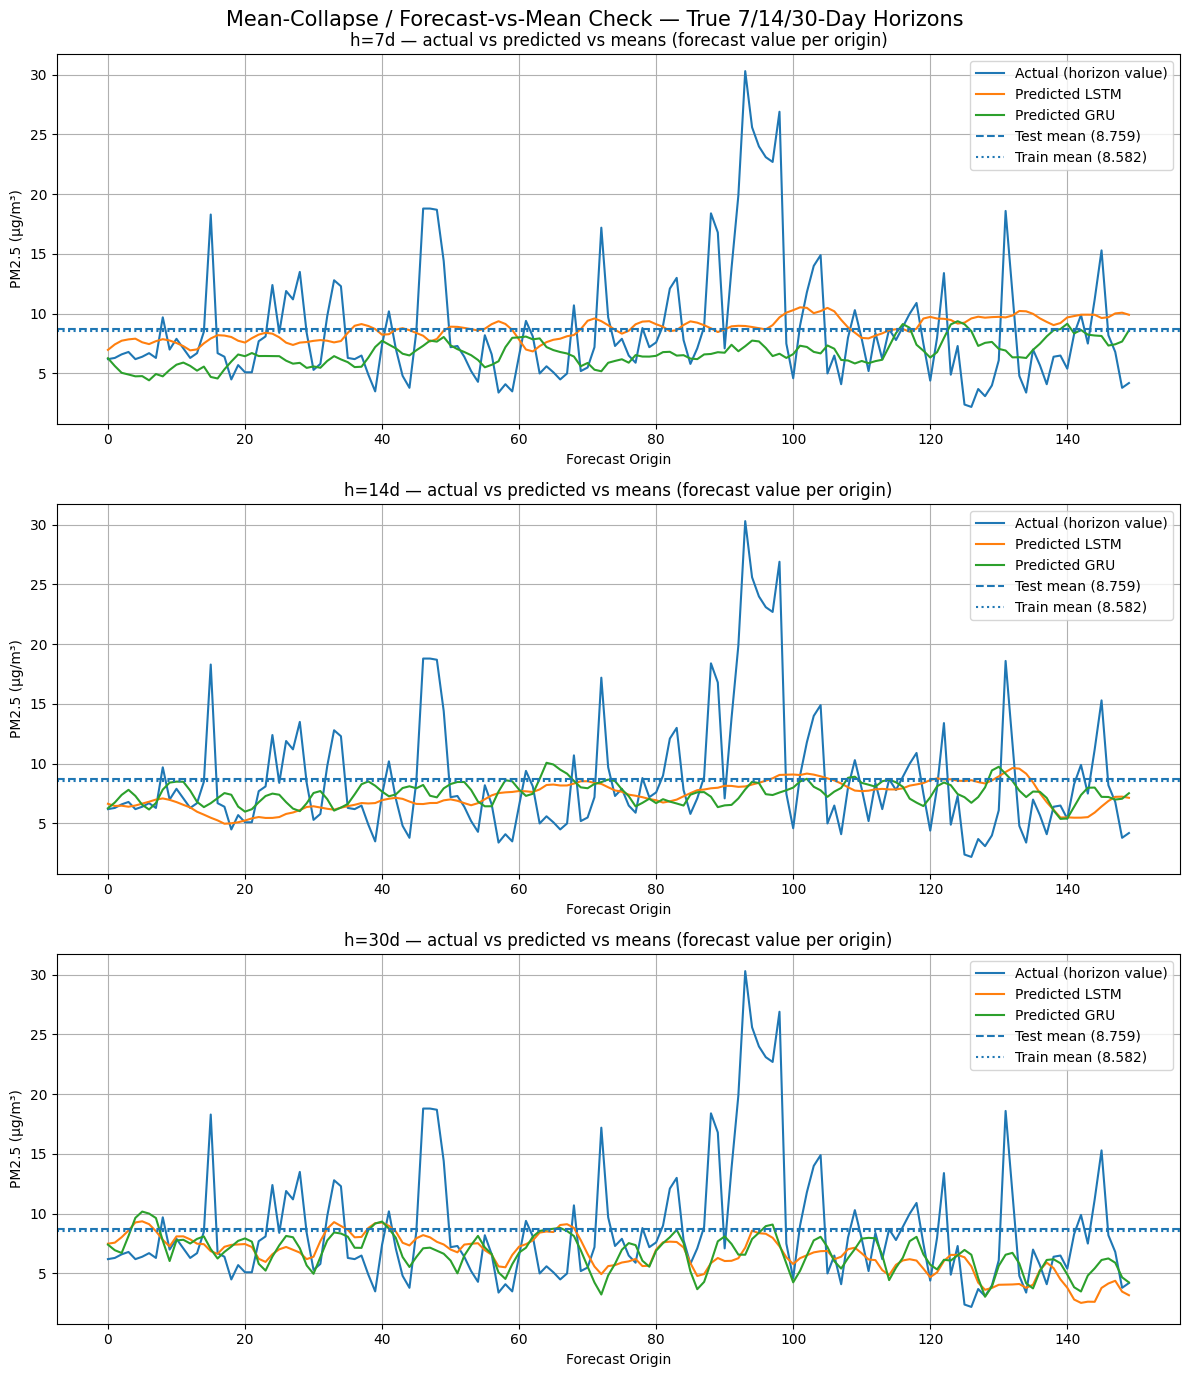

In [18]:
# ============================================================
# 16. MEAN COLLAPSE CHECK — HORIZON FORECASTS
# ============================================================
train_mean = df.loc[:train_end - 1, TARGET].mean()
test_mean = df.loc[val_end:, TARGET].mean()

fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=False)

for ax, horizon in zip(axes, HORIZONS):
    # Use LSTM and GRU horizon-specific predictions.
    lstm_result = predictions[("LSTM", horizon)]
    gru_result = predictions[("GRU", horizon)]

    # Actual horizon target series is the same for both models.
    ax.plot(
        lstm_result["y_true"],
        label="Actual (horizon value)"
    )
    ax.plot(
        lstm_result["y_pred"],
        label="Predicted LSTM"
    )
    ax.plot(
        gru_result["y_pred"],
        label="Predicted GRU"
    )

    ax.axhline(
        test_mean,
        linestyle="--",
        label=f"Test mean ({test_mean:.3f})"
    )
    ax.axhline(
        train_mean,
        linestyle=":",
        label=f"Train mean ({train_mean:.3f})"
    )

    ax.set_title(
        f"h={horizon}d — actual vs predicted vs means "
        "(forecast value per origin)"
    )
    ax.set_xlabel("Forecast Origin")
    ax.set_ylabel("PM2.5 (µg/m³)")
    ax.grid(True)
    ax.legend(loc="upper right")

plt.suptitle(
    "Mean-Collapse / Forecast-vs-Mean Check — True 7/14/30-Day Horizons",
    fontsize=15
)
plt.tight_layout()
plt.show()

### How to read the mean-collapse check

The horizontal lines are the **training-set mean** and **test-set mean**. If the forecasts collapse toward a nearly constant value, the predicted line will stay close to one of these mean levels and fail to follow the movement in the actual horizon values.

This plot is therefore a diagnostic, not a replacement for RMSE, MAE, R², MAPE, MSE, and MBE.

## 17. Scatter: Actual vs Predicted

These scatter plots show the relationship between actual and predicted PM2.5 values for each model and forecast horizon. A perfect prediction would lie on the diagonal line. These plots help in identifying bias and the spread of predictions around the true values.

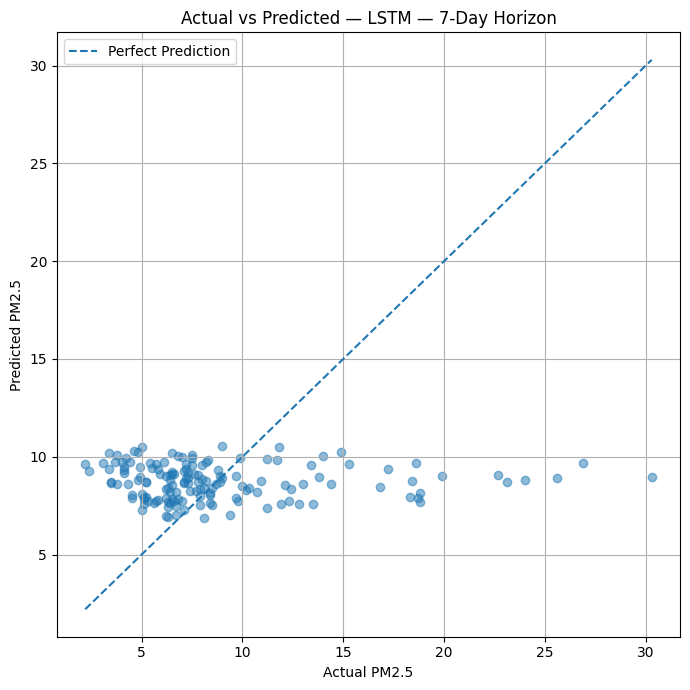

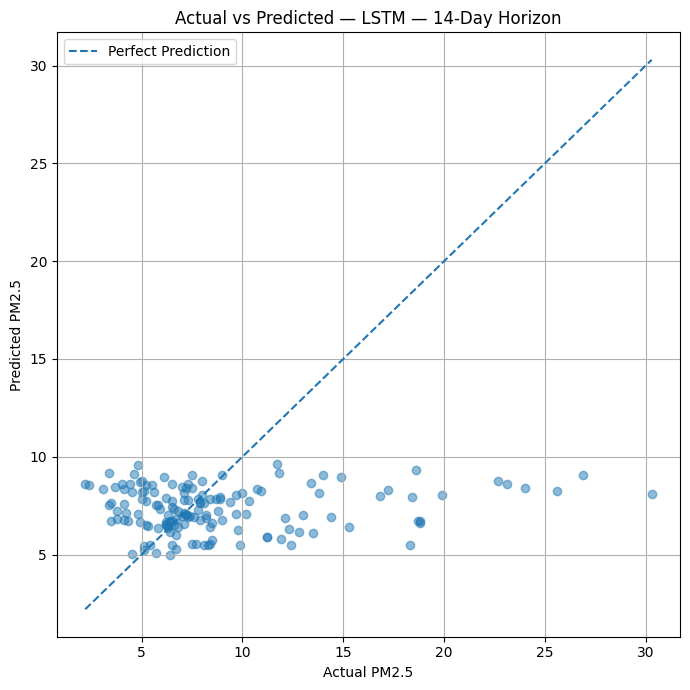

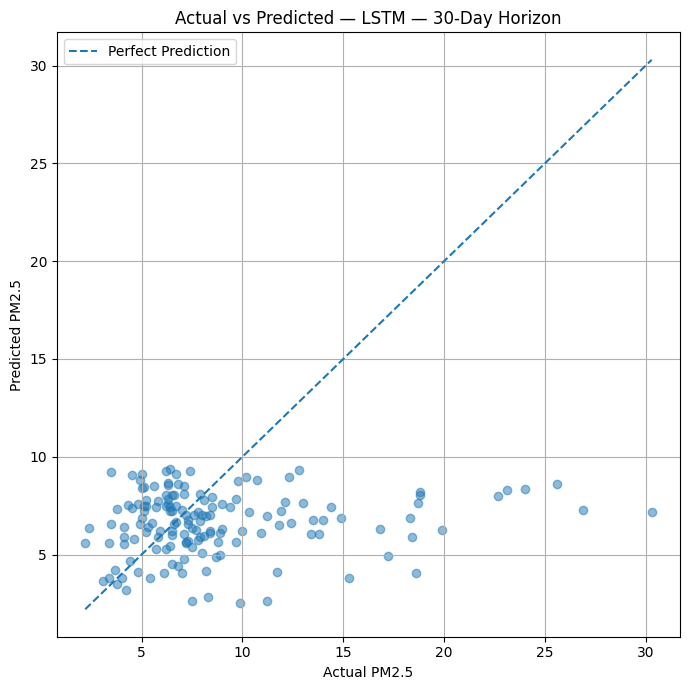

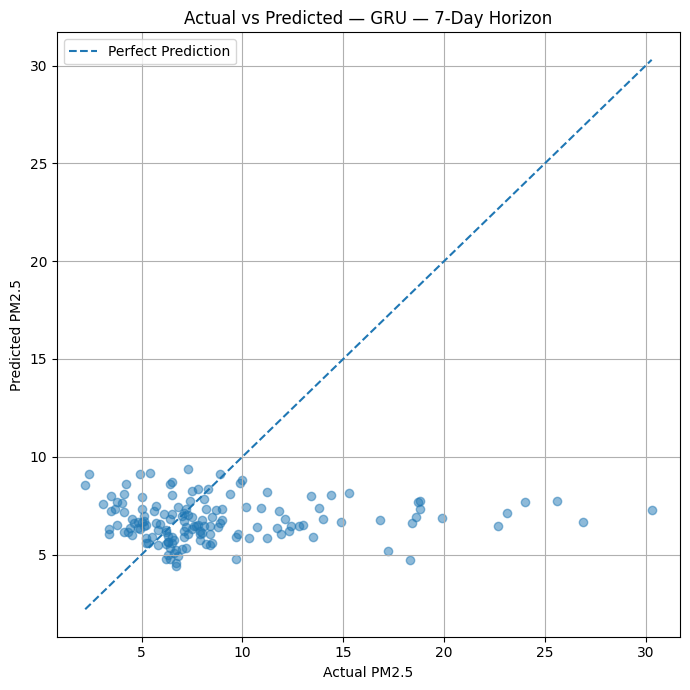

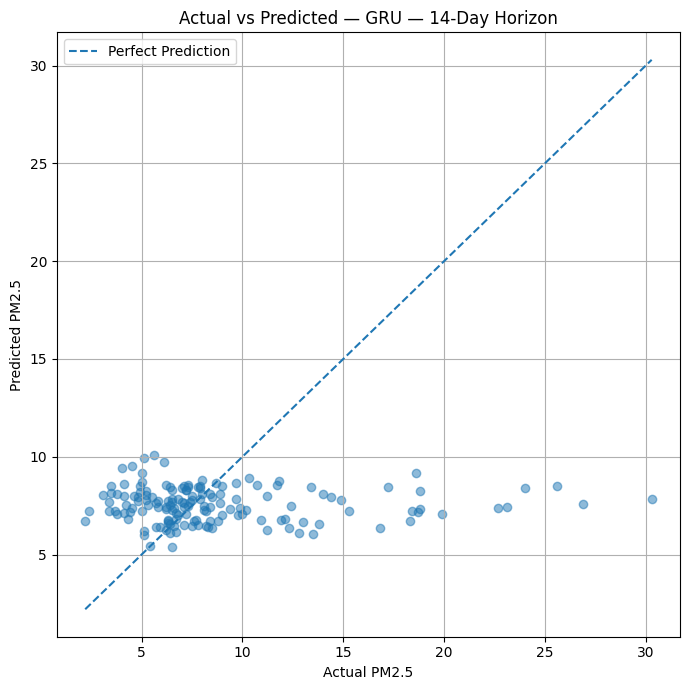

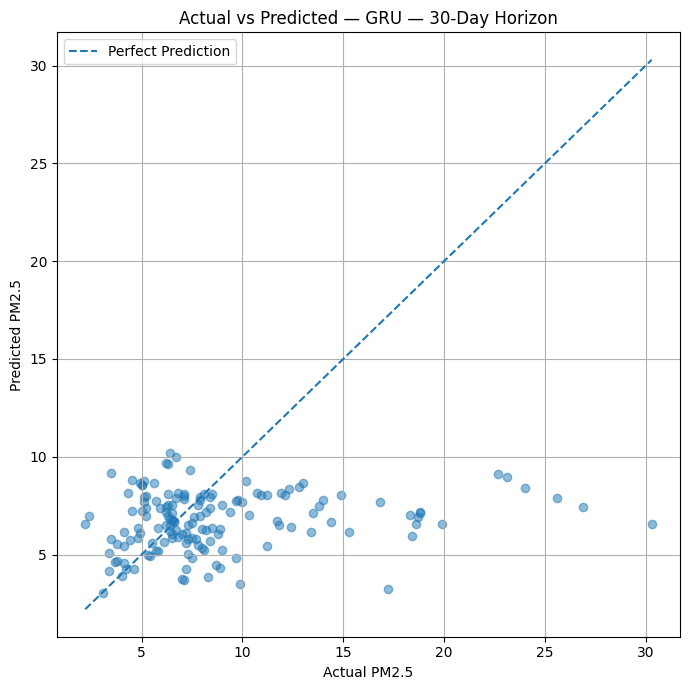

In [19]:
# ============================================================
# 17. SCATTER: ACTUAL VS PREDICTED
# ============================================================
for model_type in ["LSTM", "GRU"]:
    for horizon in HORIZONS:
        result = predictions[(model_type, horizon)]

        y_true = result["y_true"]
        y_pred = result["y_pred"]

        lower = min(y_true.min(), y_pred.min())
        upper = max(y_true.max(), y_pred.max())

        plt.figure(figsize=(7, 7))
        plt.scatter(y_true, y_pred, alpha=0.5)
        plt.plot(
            [lower, upper],
            [lower, upper],
            linestyle="--",
            label="Perfect Prediction"
        )

        plt.xlabel("Actual PM2.5")
        plt.ylabel("Predicted PM2.5")
        plt.title(
            f"Actual vs Predicted — {model_type} — "
            f"{horizon}-Day Horizon"
        )
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

## 18. Residual Plots (Forecast Error)

These line plots display the residuals (actual - predicted values) over time for each model and forecast horizon. Analyzing residual patterns can reveal if the model has systematic errors or if the errors are randomly distributed, indicating a good fit.

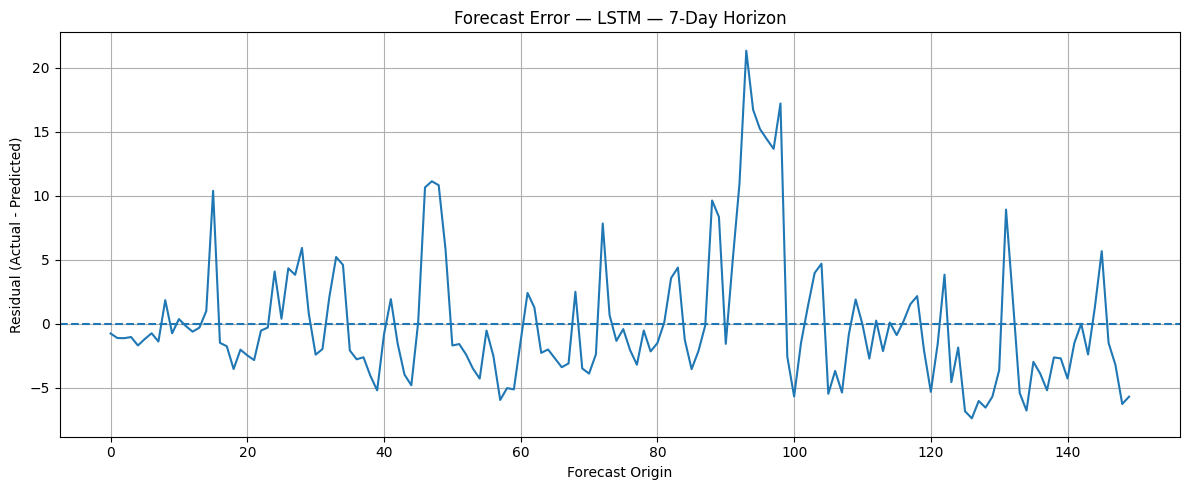

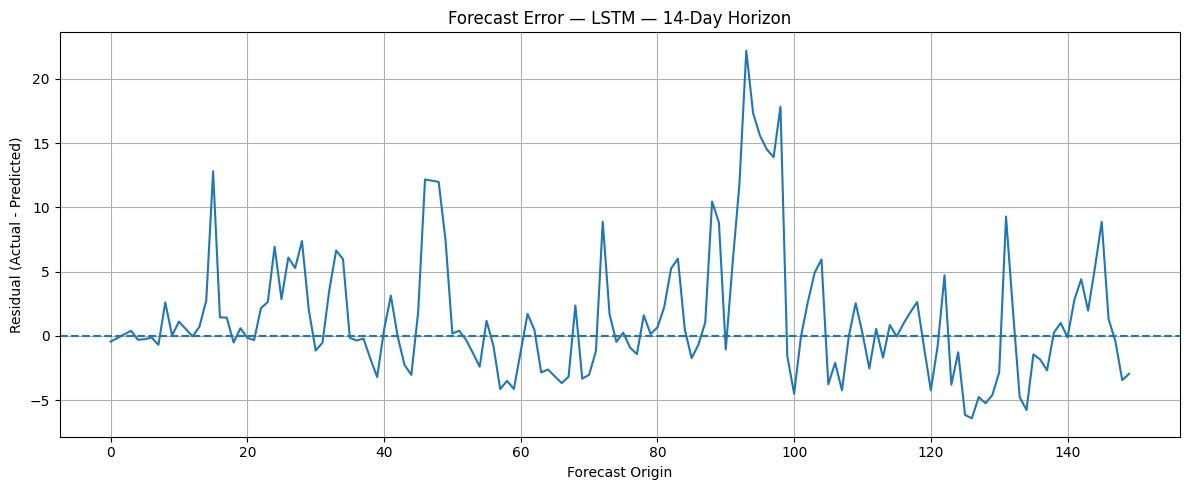

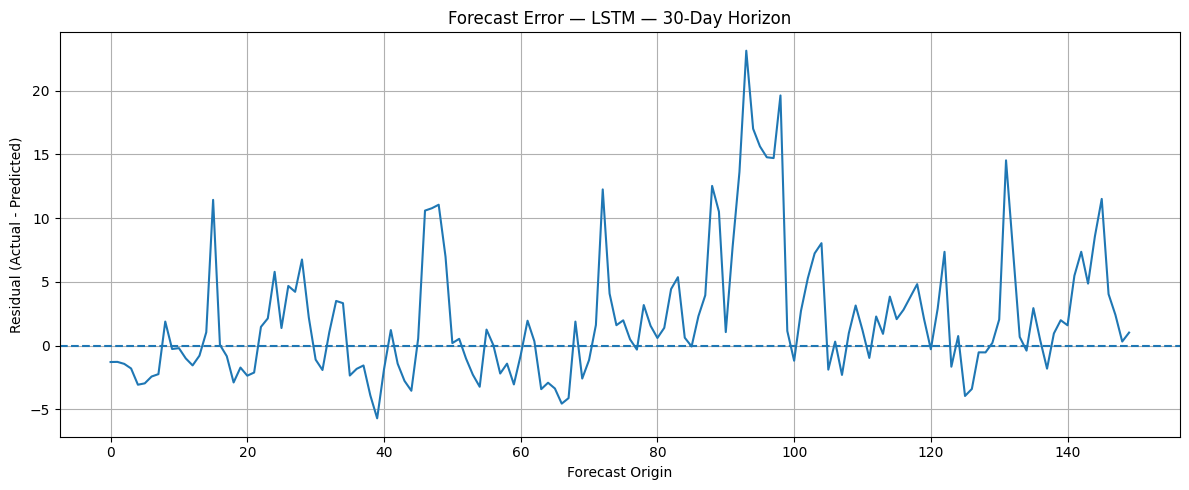

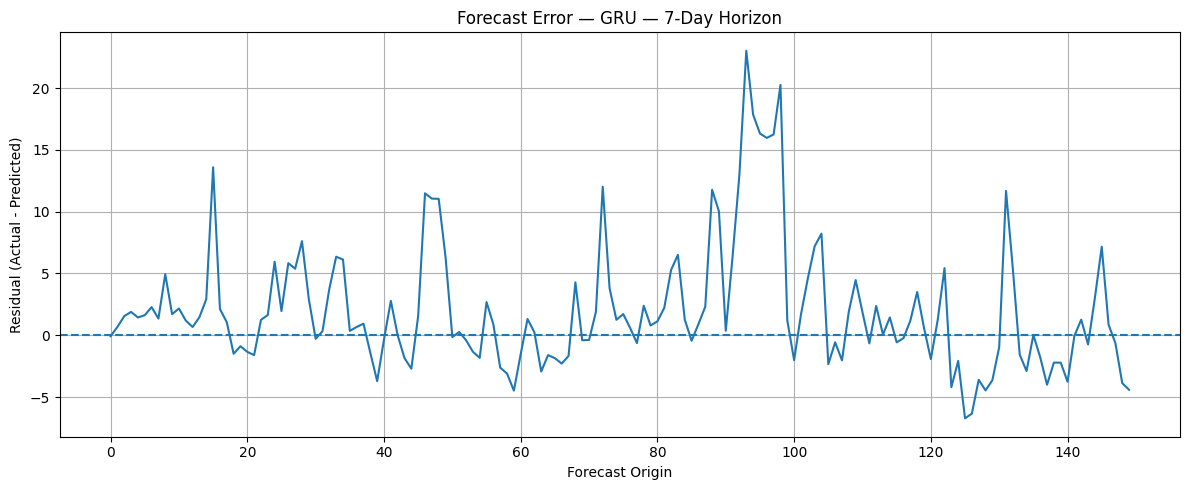

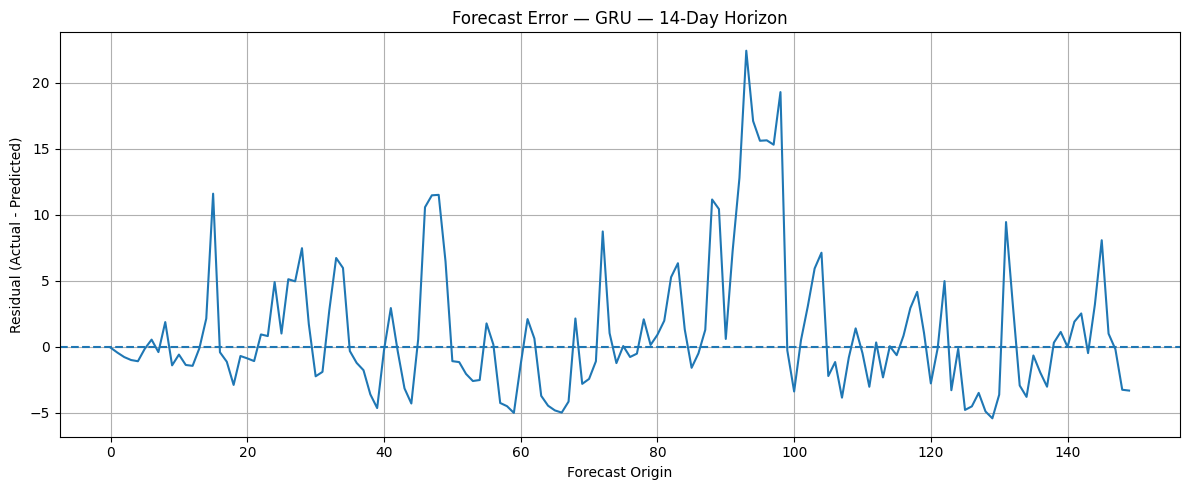

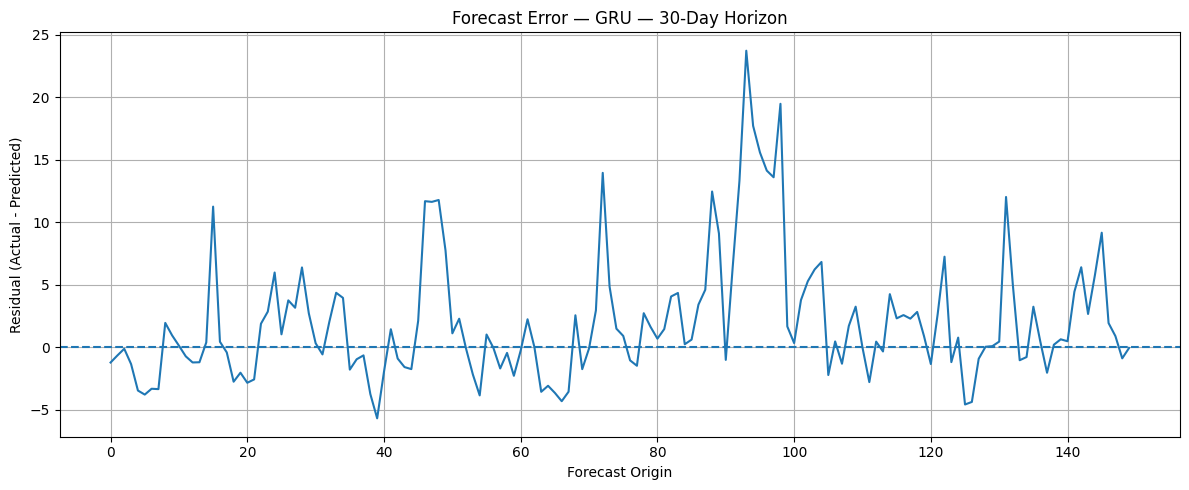

In [20]:
# ============================================================
# 18. RESIDUALS
# ============================================================
for model_type in ["LSTM", "GRU"]:
    for horizon in HORIZONS:
        result = predictions[(model_type, horizon)]
        residuals = result["y_true"] - result["y_pred"]

        plt.figure(figsize=(12, 5))
        plt.plot(residuals)
        plt.axhline(0, linestyle="--")

        plt.xlabel("Forecast Origin")
        plt.ylabel("Residual (Actual - Predicted)")
        plt.title(
            f"Forecast Error — {model_type} — {horizon}-Day Horizon"
        )
        plt.grid(True)
        plt.tight_layout()
        plt.show()

##  19. Error Distributions (Residual Histograms)





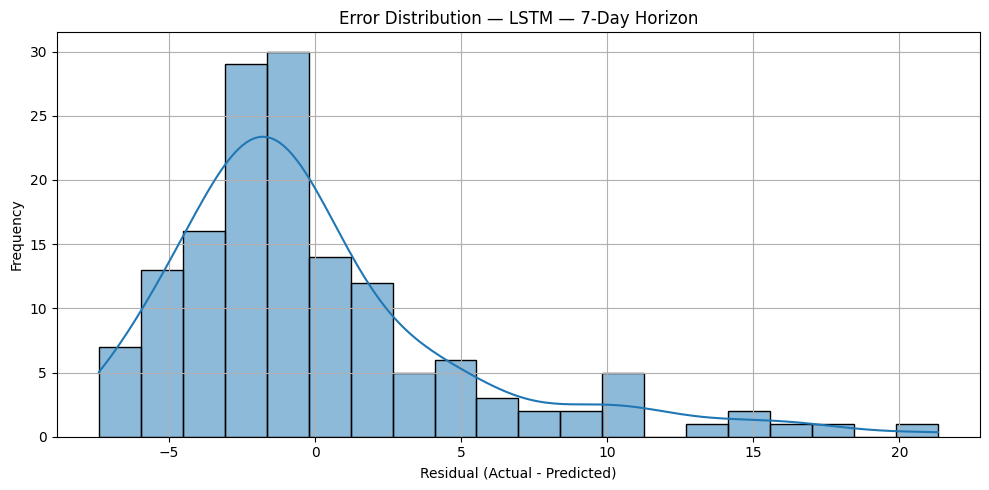

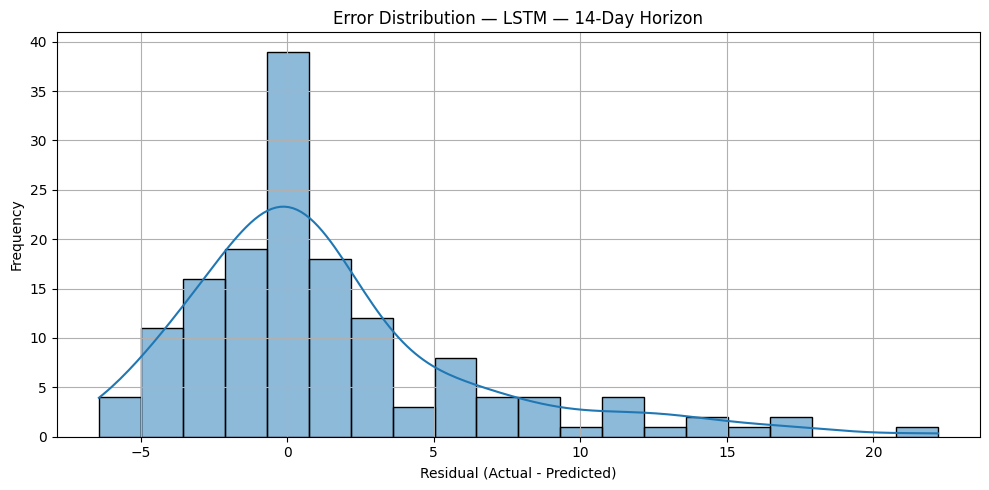

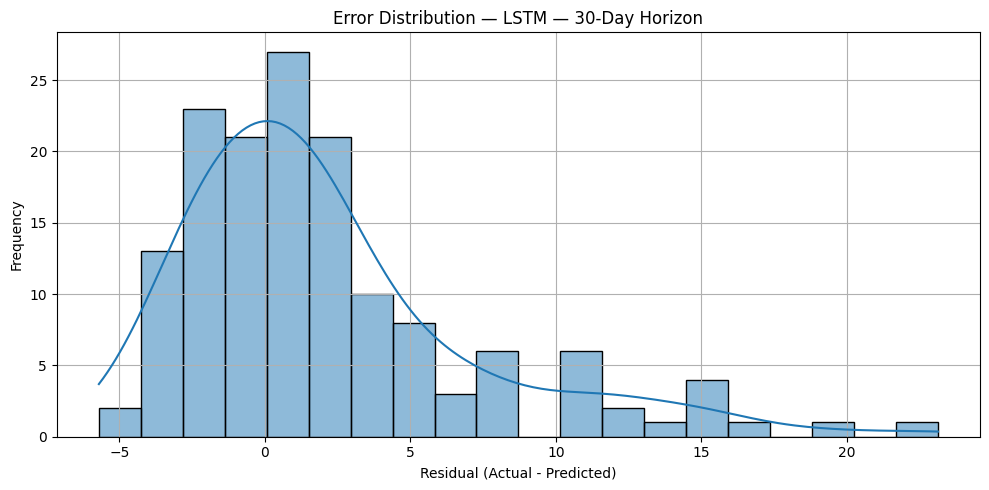

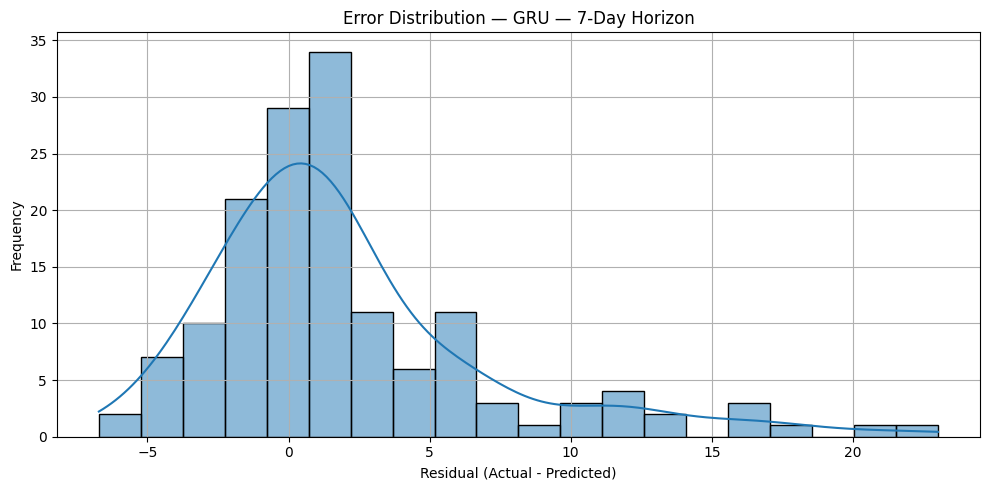

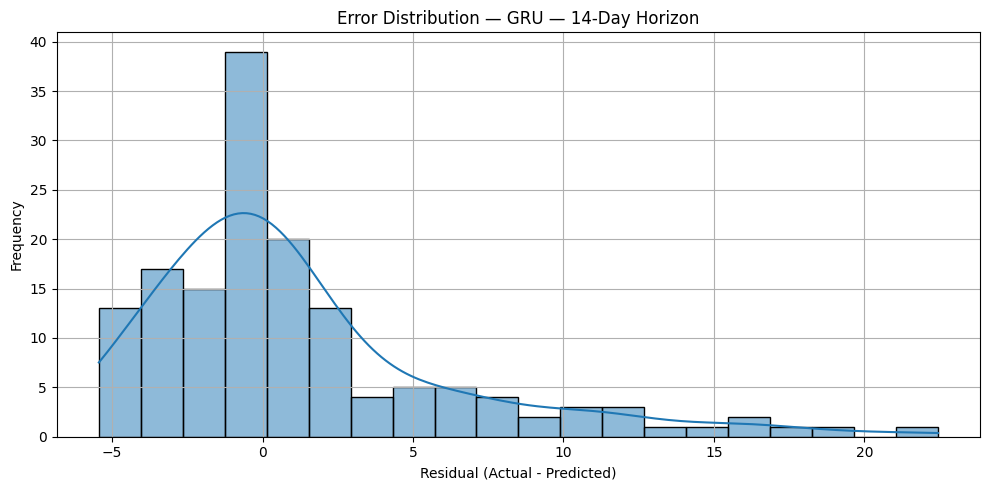

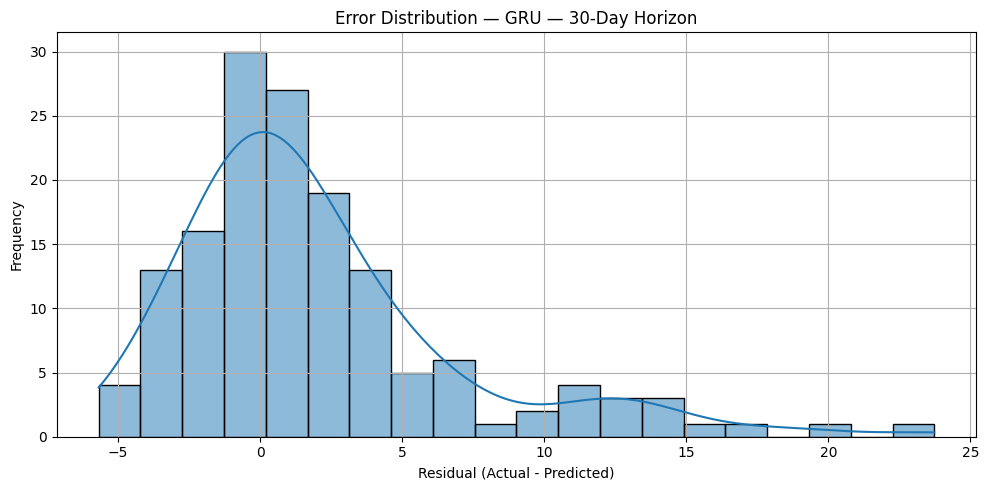

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

for model_type in ["LSTM", "GRU"]:
    for horizon in HORIZONS:
        result = predictions[(model_type, horizon)]
        residuals = result["y_true"] - result["y_pred"]

        plt.figure(figsize=(10, 5))
        sns.histplot(residuals, kde=True, bins=20)
        plt.xlabel("Residual (Actual - Predicted)")
        plt.ylabel("Frequency")
        plt.title(
            f"Error Distribution — {model_type} — {horizon}-Day Horizon"
        )
        plt.grid(True)
        plt.tight_layout()
        plt.show()

## 19. Error Distributions (Residual Histograms)

These histograms visualize the distribution of forecast residuals for each model and horizon. A desirable distribution is one that is centered around zero and normally distributed, suggesting that the model's errors are unbiased and random.

## 20.1. Q-Q Plots of Residuals (Normality Check)

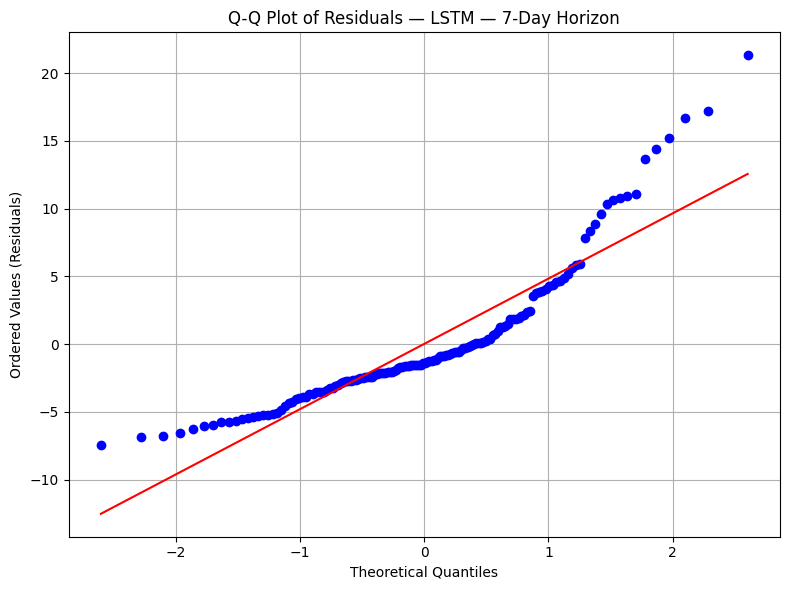

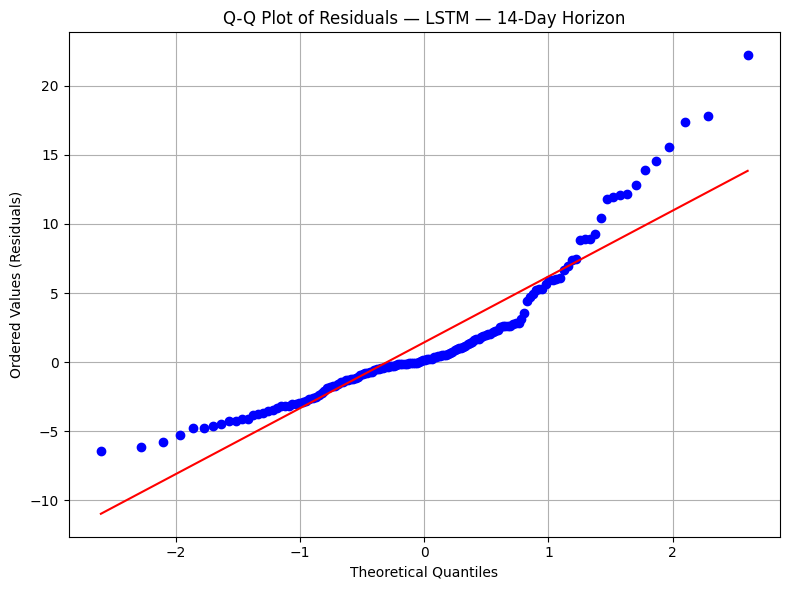

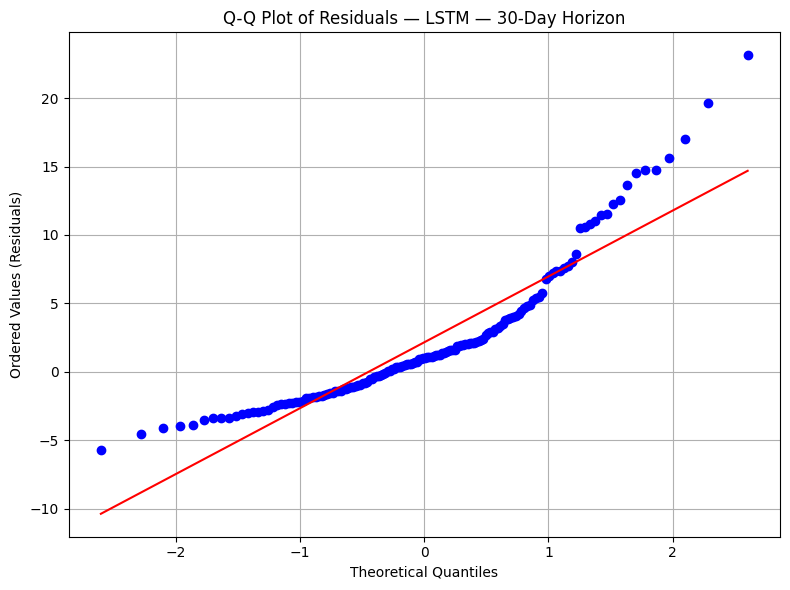

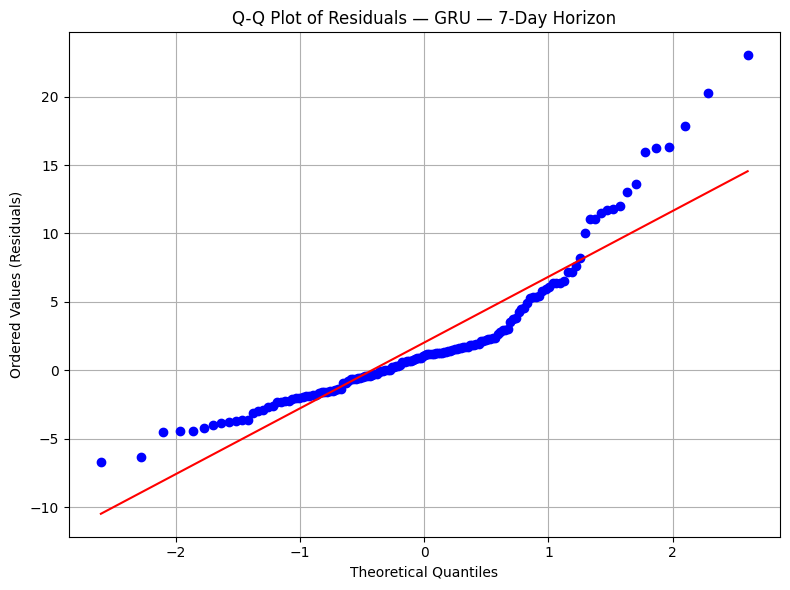

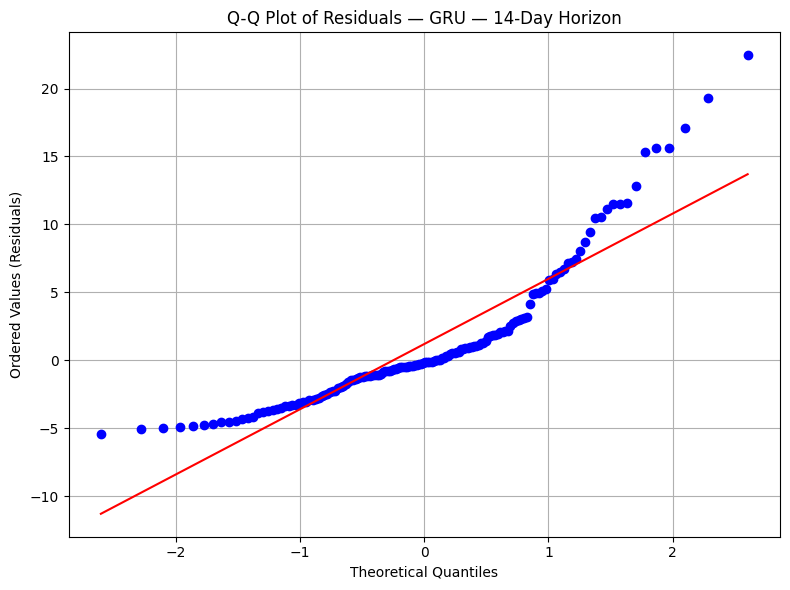

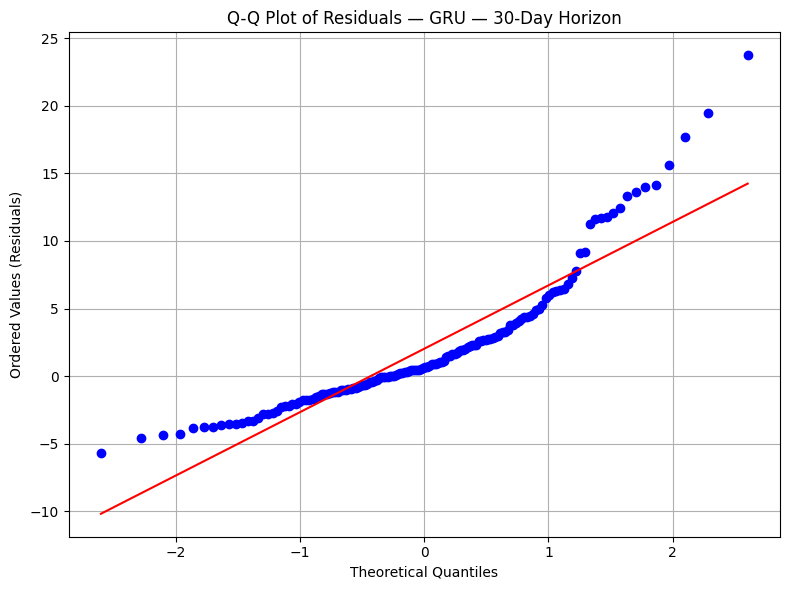

In [33]:
from scipy import stats

for model_type in ["LSTM", "GRU"]:
    for horizon in HORIZONS:
        result = predictions[(model_type, horizon)]
        residuals = result["y_true"] - result["y_pred"]

        plt.figure(figsize=(8, 6))
        stats.probplot(residuals, dist="norm", plot=plt)
        plt.title(f'Q-Q Plot of Residuals — {model_type} — {horizon}-Day Horizon')
        plt.xlabel('Theoretical Quantiles')
        plt.ylabel('Ordered Values (Residuals)')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

## 20. Q-Q Plots of Residuals (Normality Check)

These Quantile-Quantile (Q-Q) plots compare the distribution of the residuals against a theoretical normal distribution. If the residuals are normally distributed, the points should fall approximately along the 45-degree line. Deviations indicate non-normality, which can be important for certain statistical assumptions.

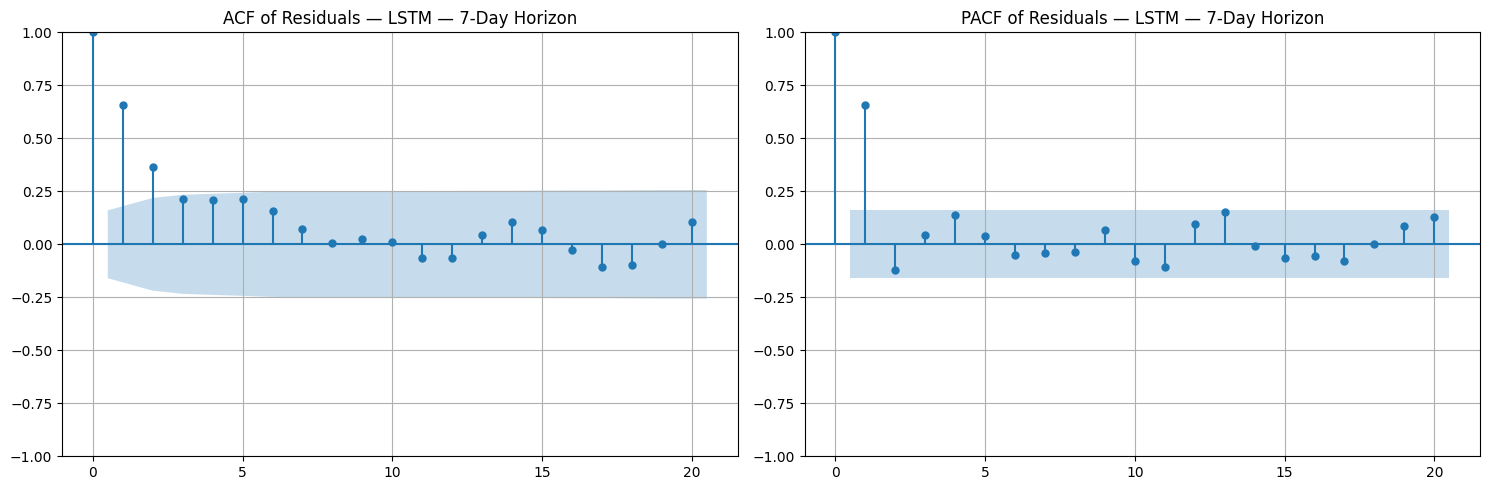

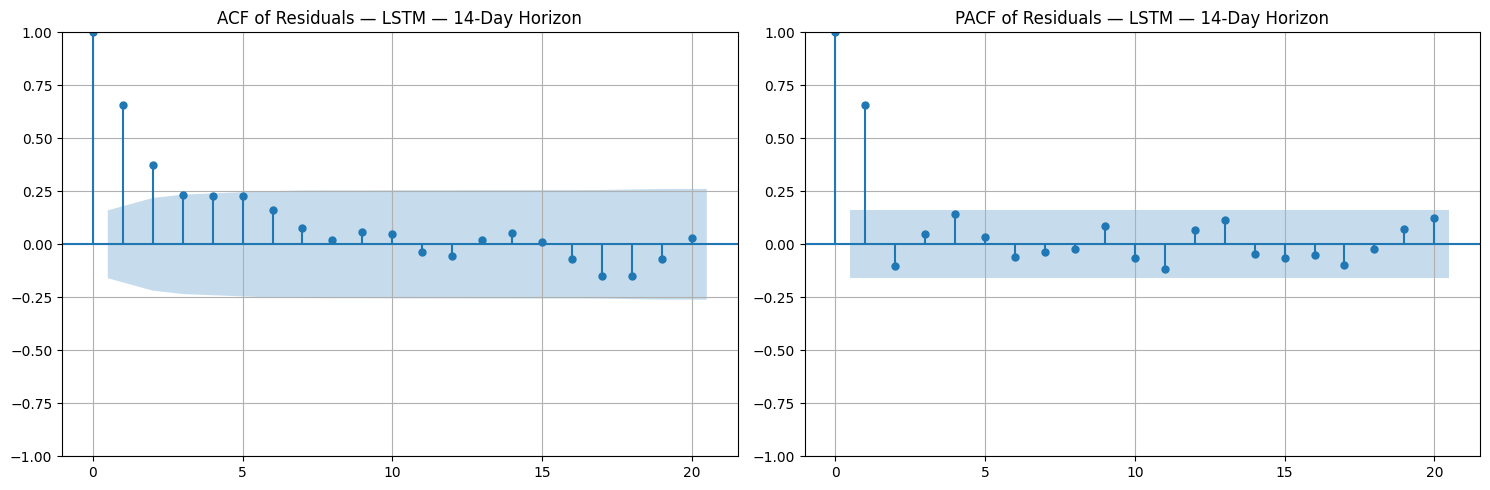

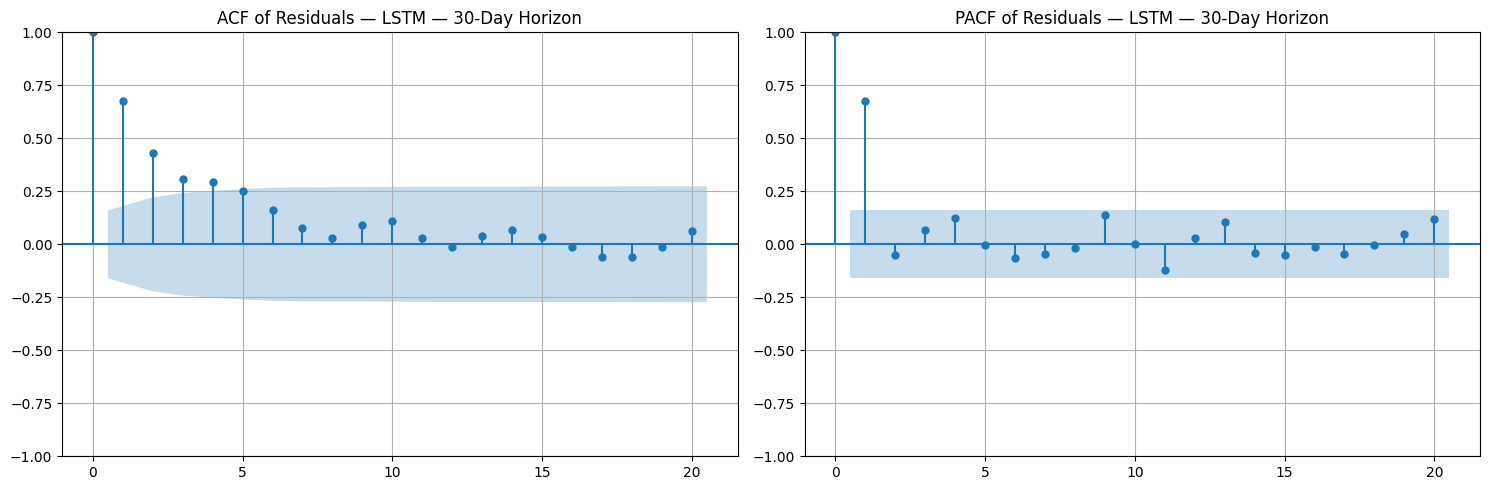

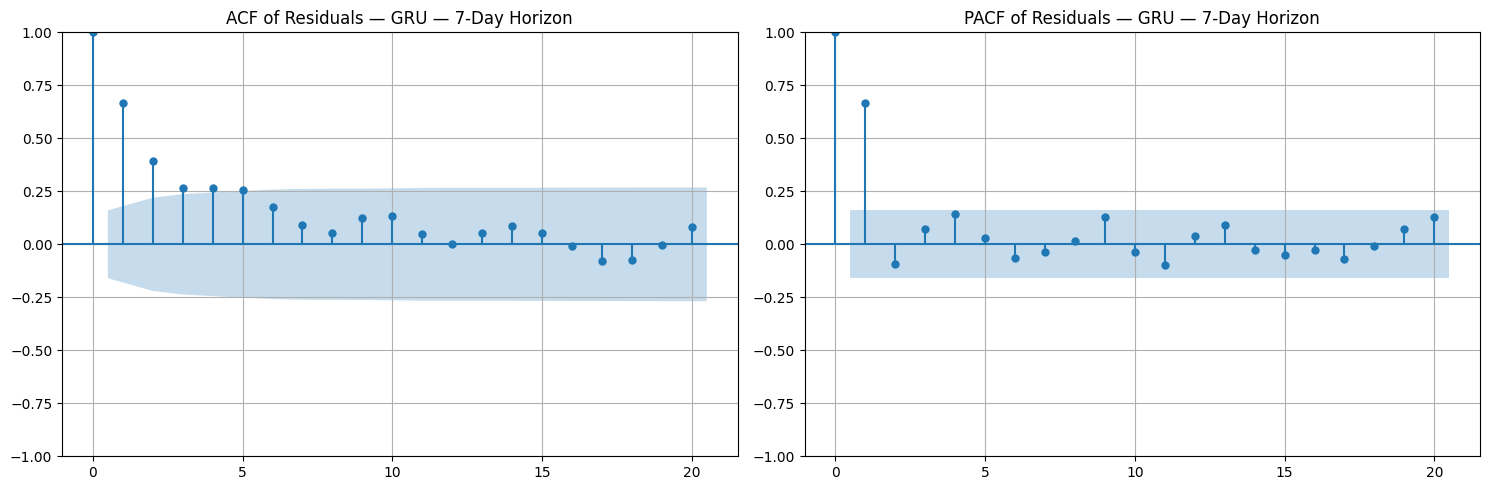

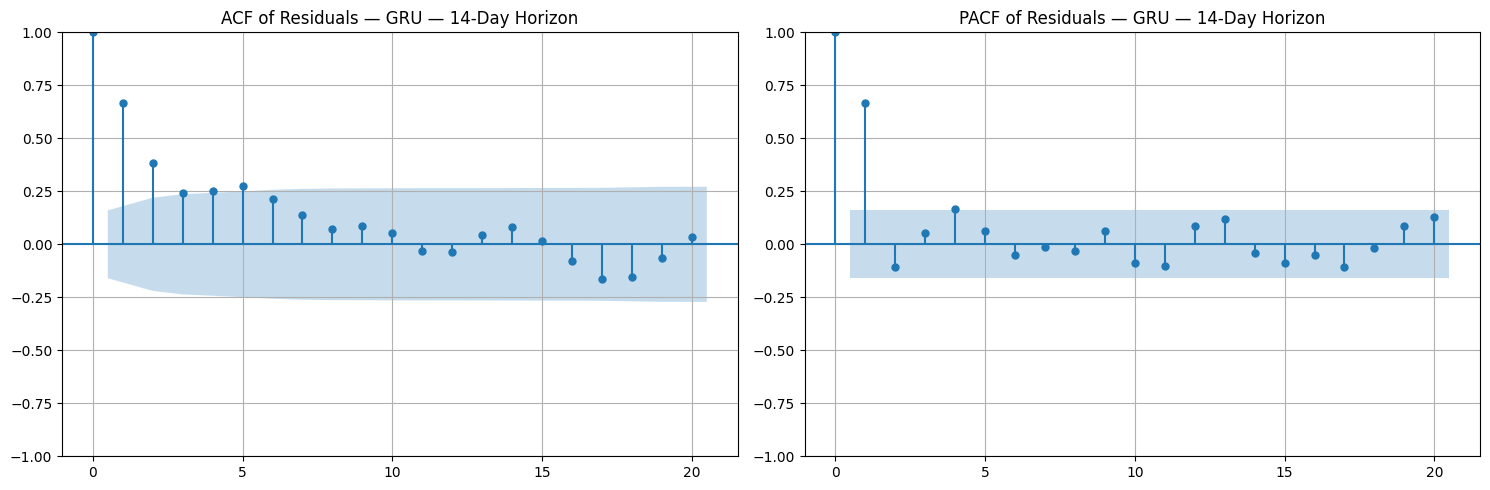

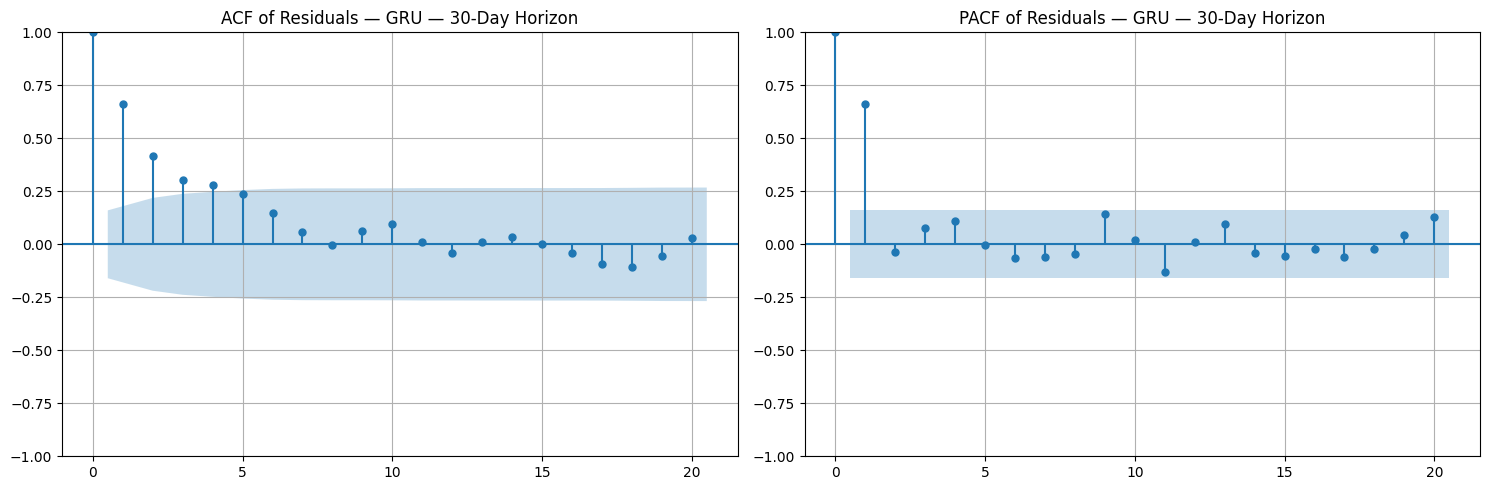

In [27]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

for model_type in ["LSTM", "GRU"]:
    for horizon in HORIZONS:
        result = predictions[(model_type, horizon)]
        residuals = result["y_true"] - result["y_pred"]

        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        # ACF plot
        plot_acf(residuals, ax=axes[0], lags=min(20, len(residuals) - 1))
        axes[0].set_title(f'ACF of Residuals — {model_type} — {horizon}-Day Horizon')
        axes[0].grid(True)

        # PACF plot
        plot_pacf(residuals, ax=axes[1], lags=min(20, len(residuals) - 1))
        axes[1].set_title(f'PACF of Residuals — {model_type} — {horizon}-Day Horizon')
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

## 21. Hyperparameter Tuning Plots

## Hyperparameter Tuning Visualizations

These plots illustrate how the best validation loss changes with different hyperparameters (Units, Dropout, Batch Size, Learning Rate) for both LSTM and GRU models across various horizons. This helps in understanding the sensitivity of model performance to hyperparameter choices.

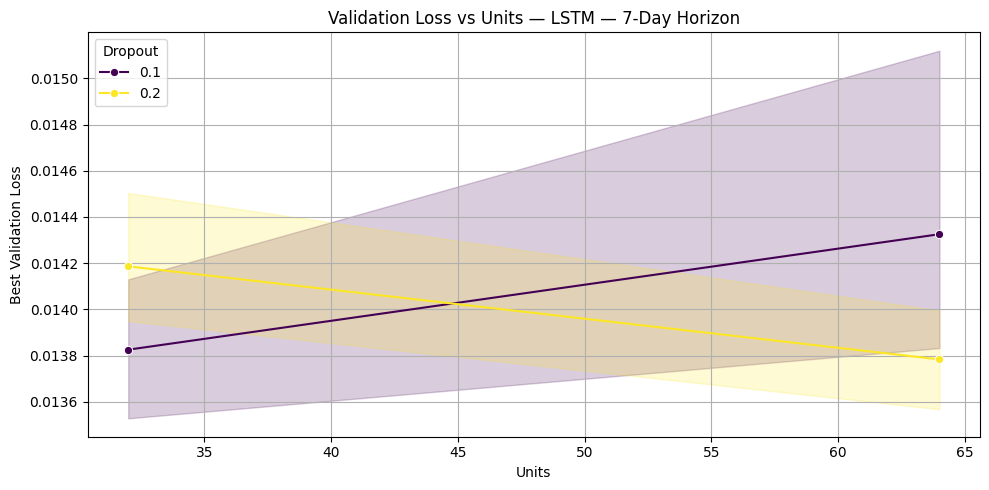

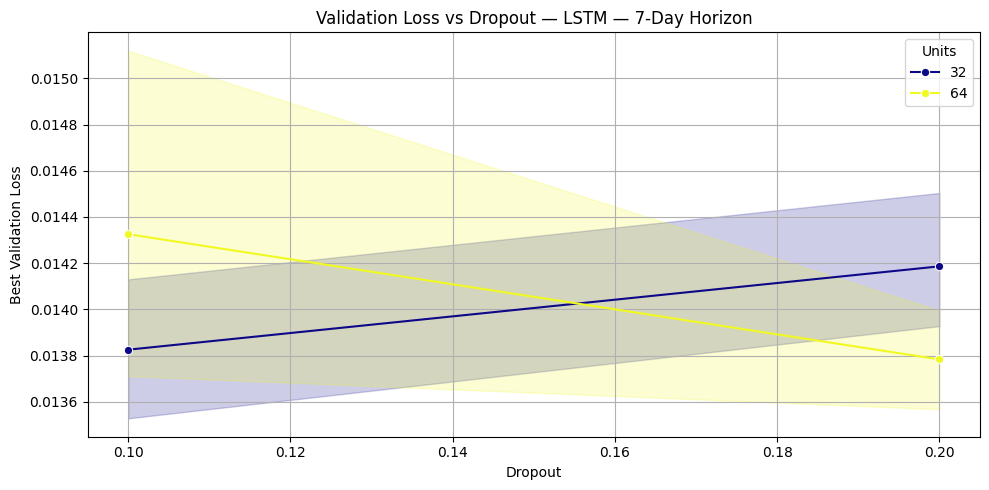

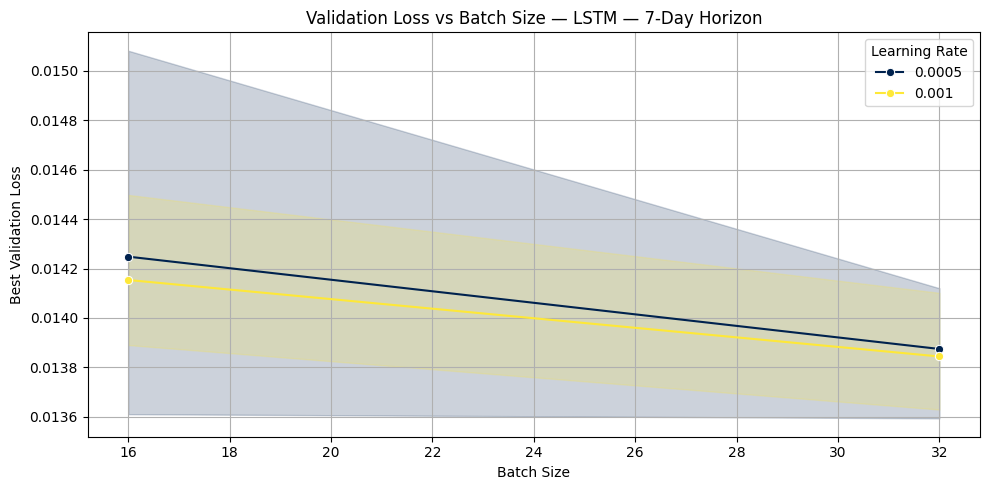

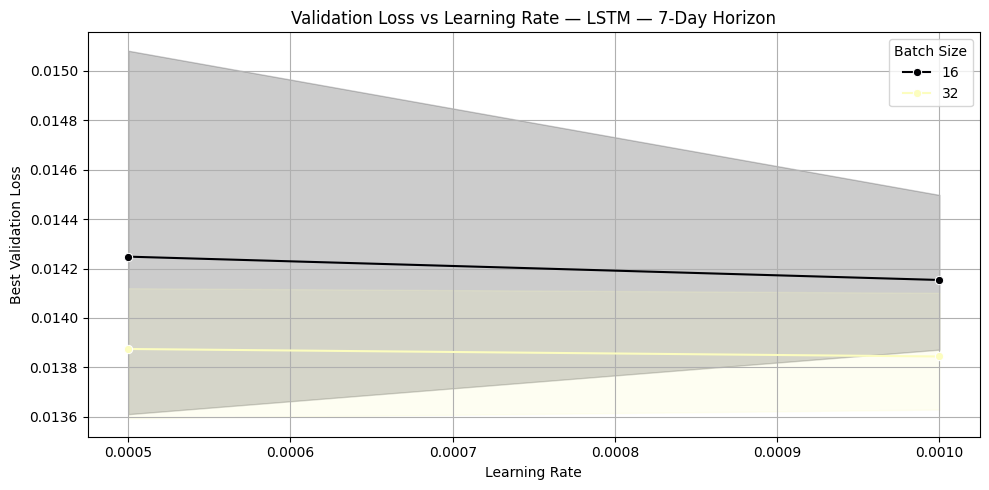

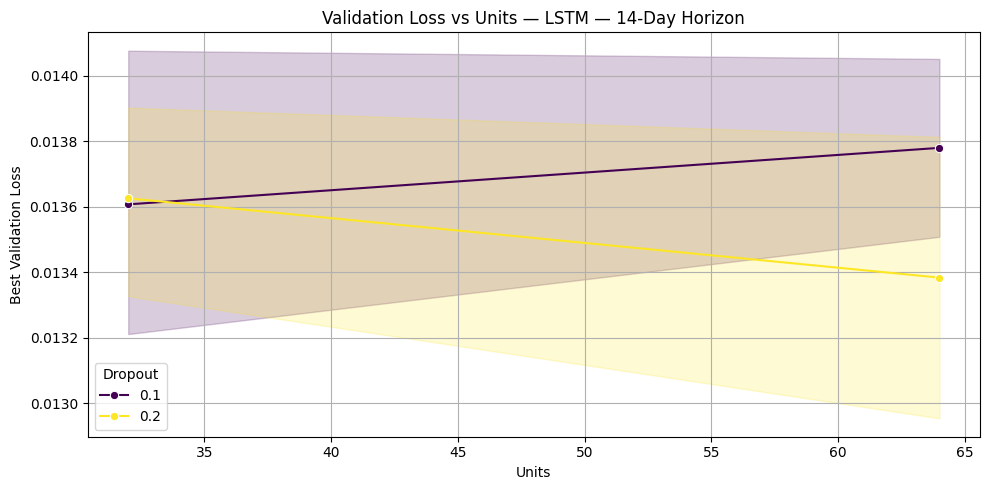

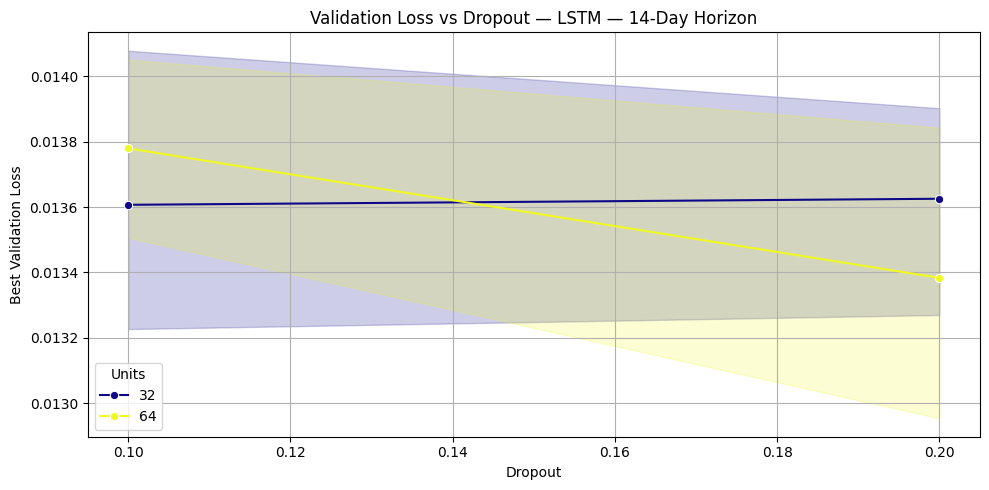

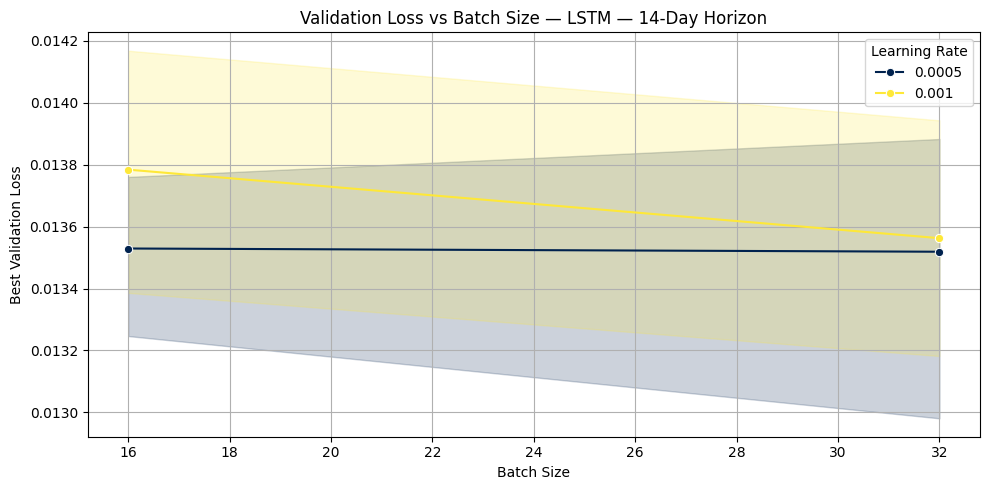

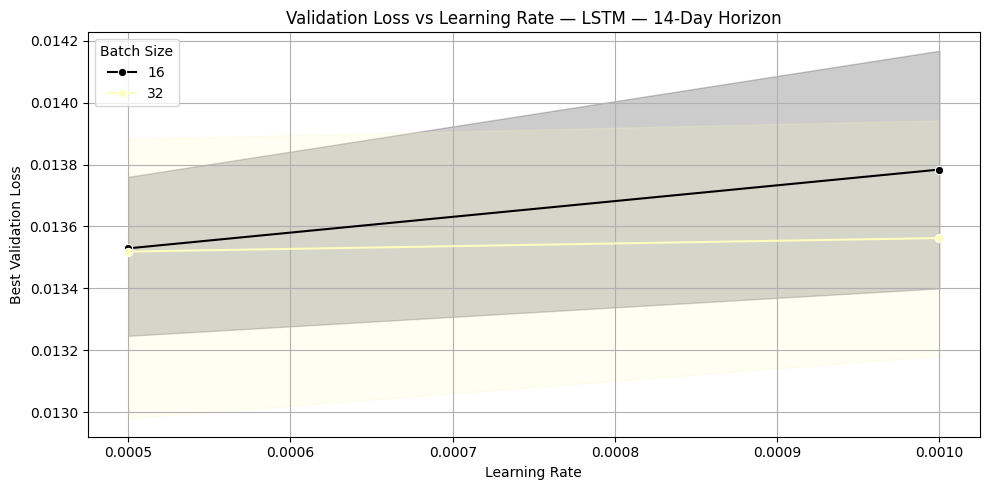

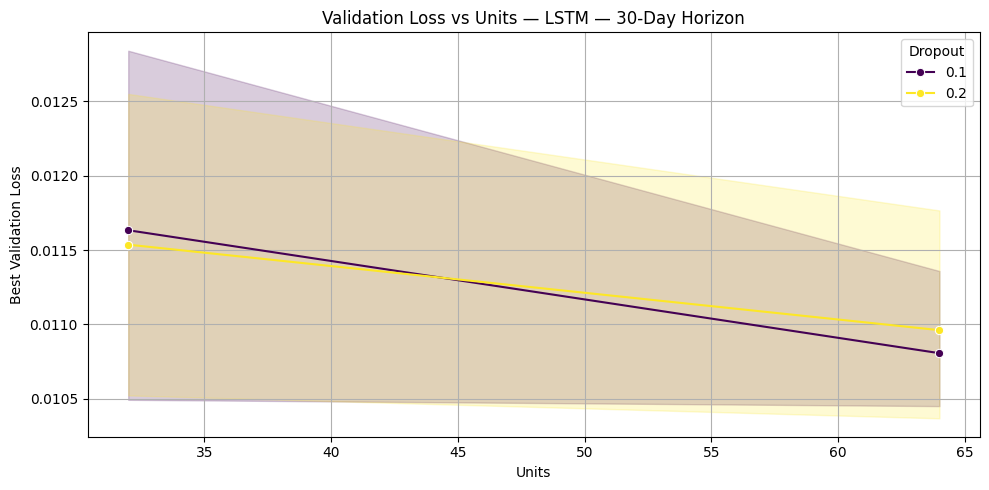

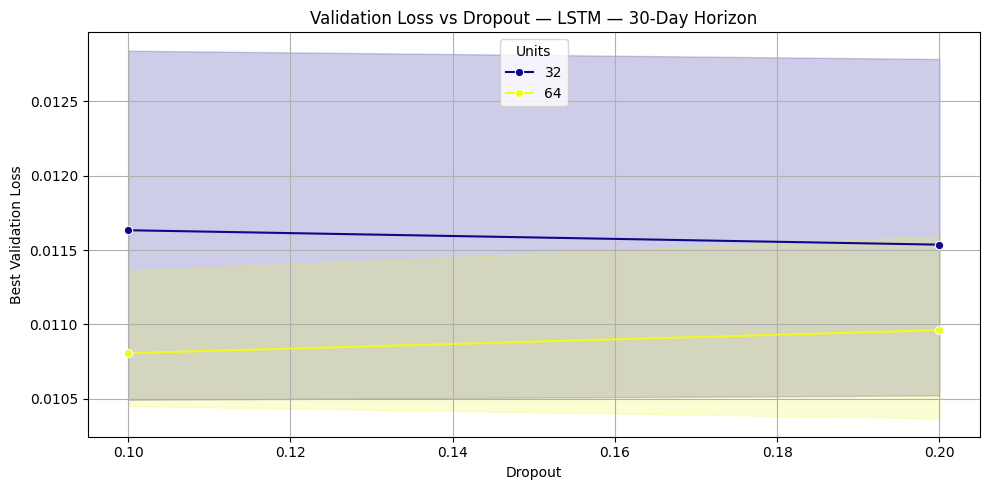

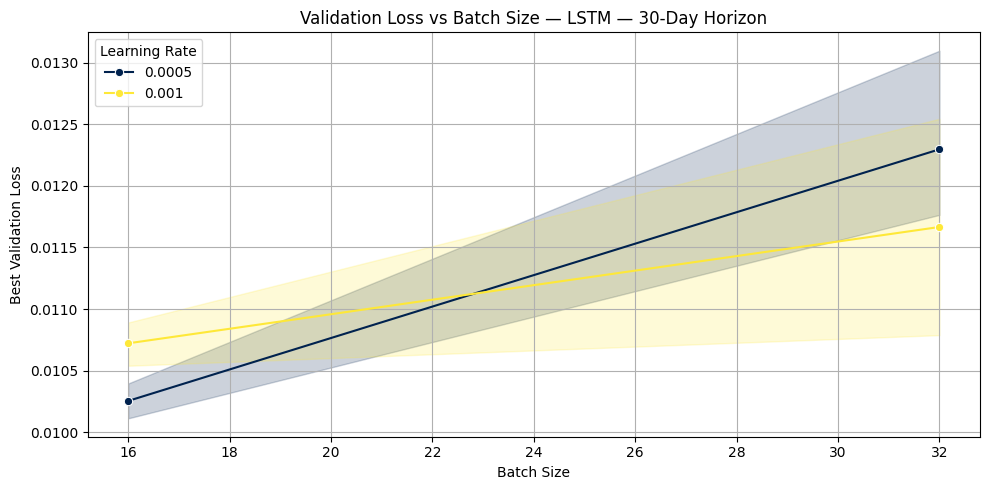

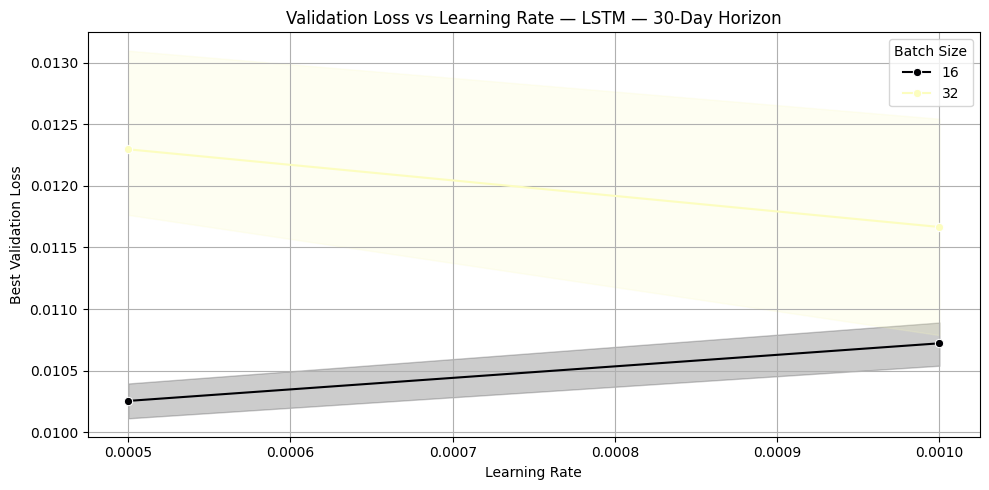

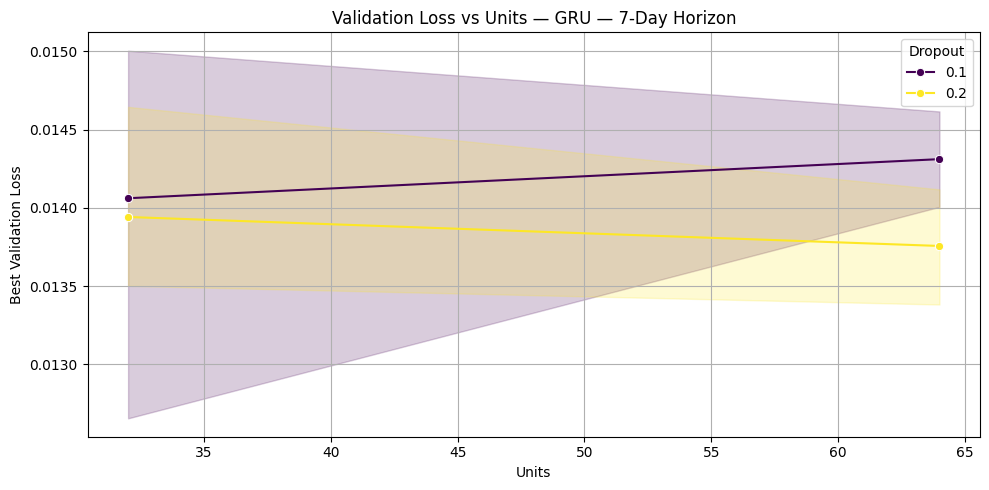

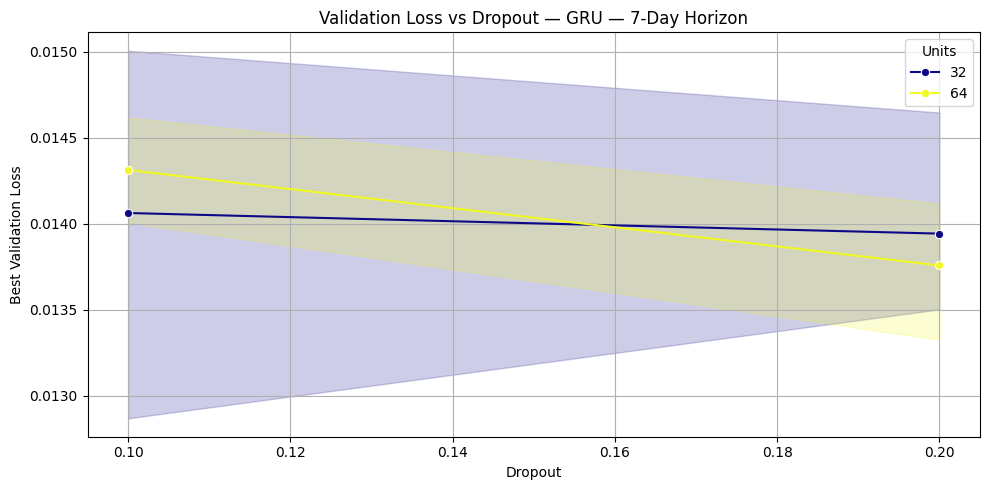

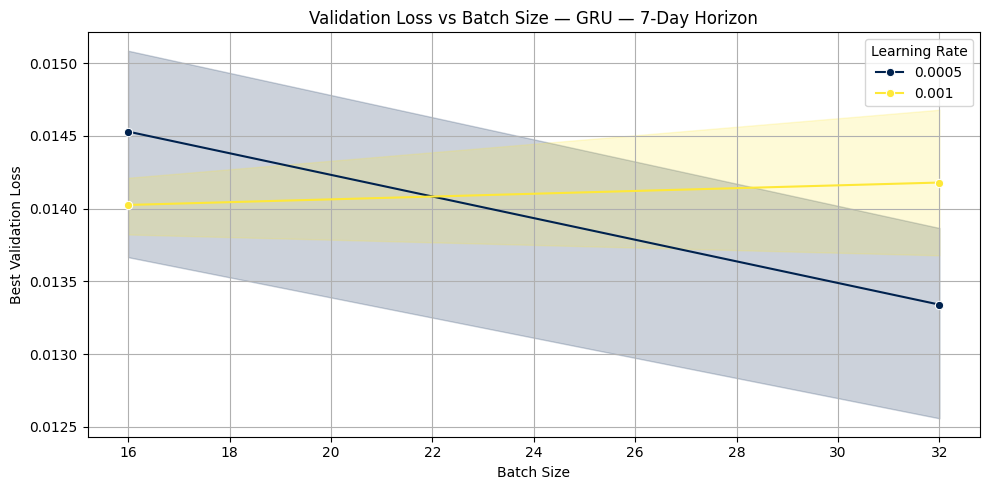

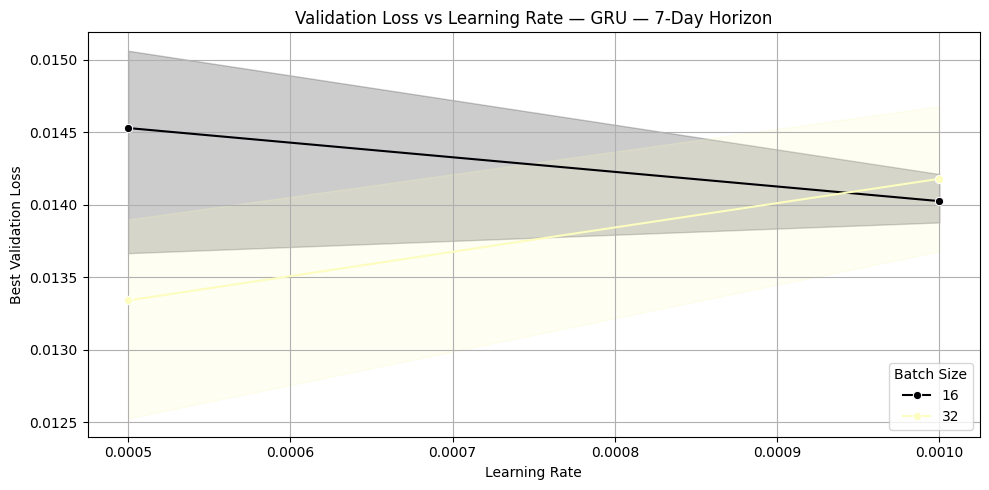

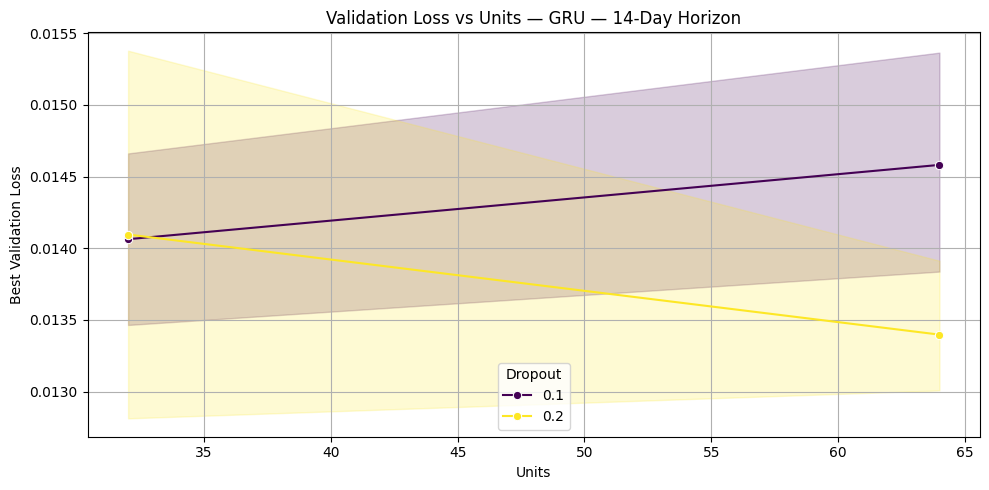

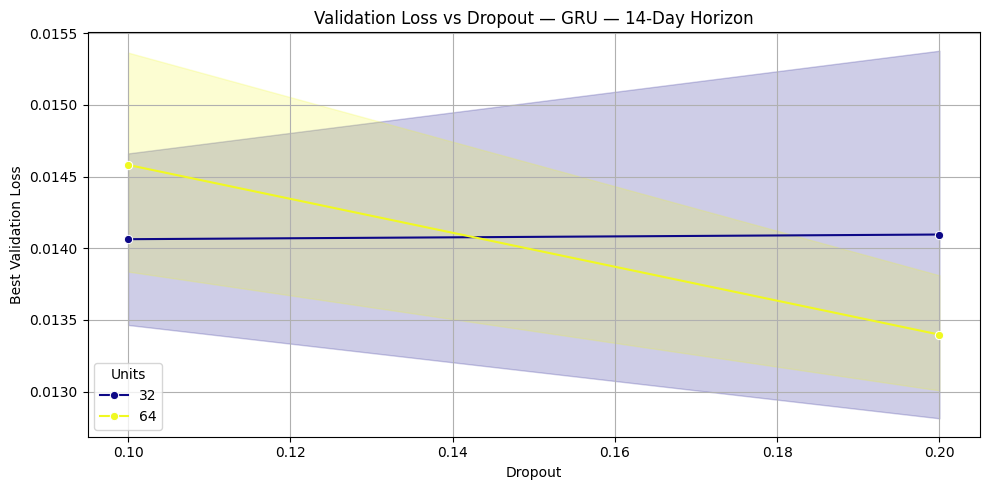

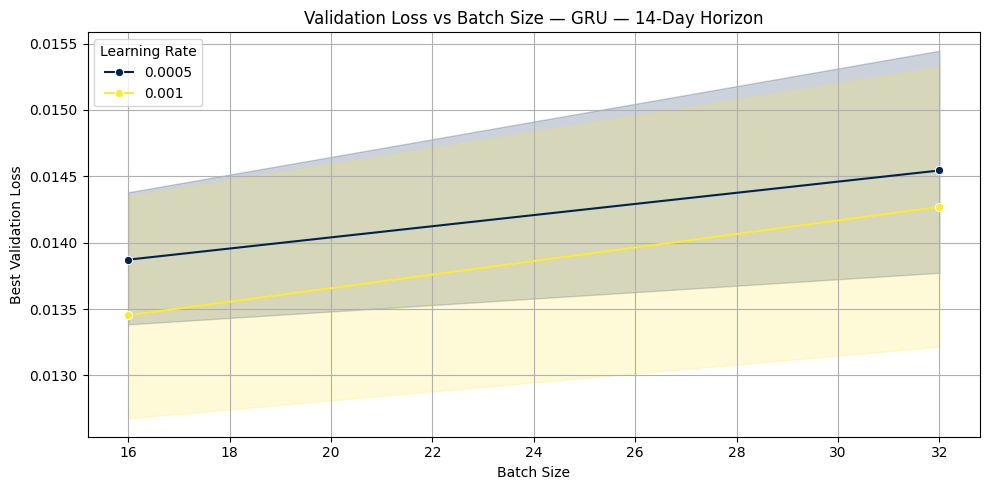

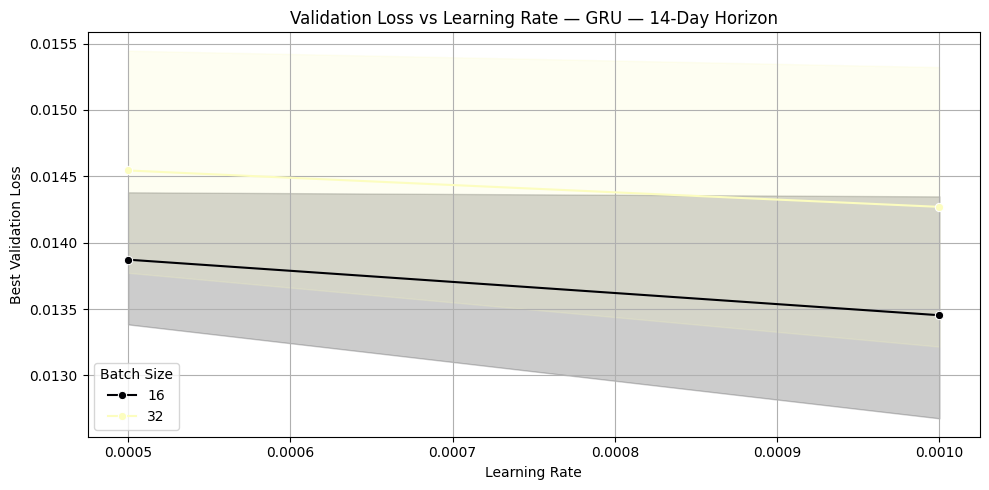

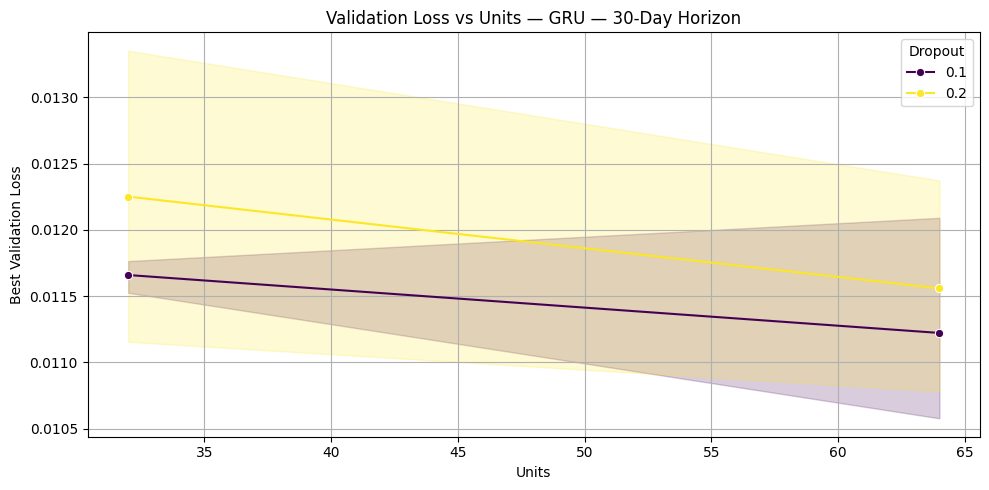

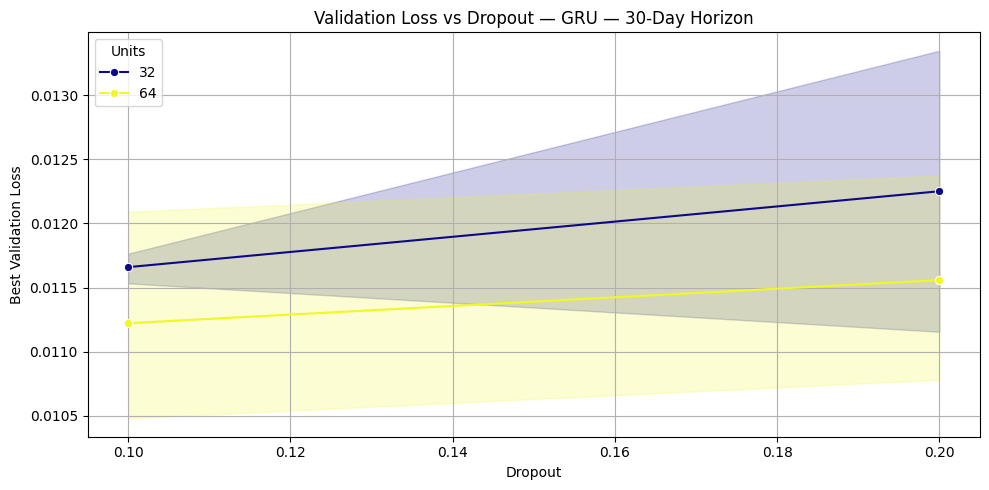

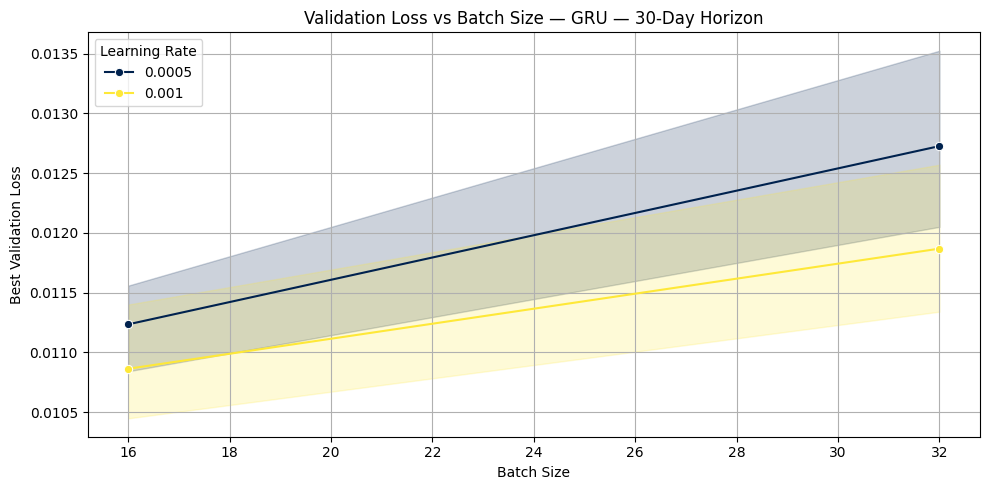

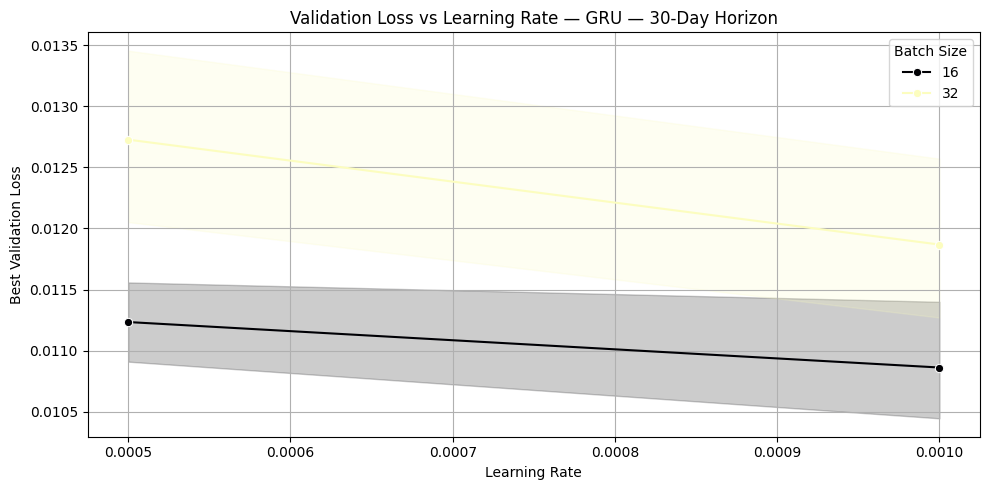

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

for model_type in ["LSTM", "GRU"]:
    for horizon in HORIZONS:
        subset_tuning = tuning_df[
            (tuning_df["Model"] == model_type) &
            (tuning_df["Horizon"] == horizon)
        ]

        # Plot for Units
        plt.figure(figsize=(10, 5))
        sns.lineplot(
            data=subset_tuning,
            x="Units",
            y="Best_Validation_Loss",
            hue="Dropout",
            marker="o",
            palette="viridis"
        )
        plt.title(f'Validation Loss vs Units — {model_type} — {horizon}-Day Horizon')
        plt.xlabel("Units")
        plt.ylabel("Best Validation Loss")
        plt.grid(True)
        plt.legend(title="Dropout")
        plt.tight_layout()
        plt.show()

        # Plot for Dropout
        plt.figure(figsize=(10, 5))
        sns.lineplot(
            data=subset_tuning,
            x="Dropout",
            y="Best_Validation_Loss",
            hue="Units",
            marker="o",
            palette="plasma"
        )
        plt.title(f'Validation Loss vs Dropout — {model_type} — {horizon}-Day Horizon')
        plt.xlabel("Dropout")
        plt.ylabel("Best Validation Loss")
        plt.grid(True)
        plt.legend(title="Units")
        plt.tight_layout()
        plt.show()

        # Plot for Batch Size
        plt.figure(figsize=(10, 5))
        sns.lineplot(
            data=subset_tuning,
            x="Batch_Size",
            y="Best_Validation_Loss",
            hue="Learning_Rate",
            marker="o",
            palette="cividis"
        )
        plt.title(f'Validation Loss vs Batch Size — {model_type} — {horizon}-Day Horizon')
        plt.xlabel("Batch Size")
        plt.ylabel("Best Validation Loss")
        plt.grid(True)
        plt.legend(title="Learning Rate")
        plt.tight_layout()
        plt.show()

        # Plot for Learning Rate
        plt.figure(figsize=(10, 5))
        sns.lineplot(
            data=subset_tuning,
            x="Learning_Rate",
            y="Best_Validation_Loss",
            hue="Batch_Size",
            marker="o",
            palette="magma"
        )
        plt.title(f'Validation Loss vs Learning Rate — {model_type} — {horizon}-Day Horizon')
        plt.xlabel("Learning Rate")
        plt.ylabel("Best Validation Loss")
        plt.grid(True)
        plt.legend(title="Batch Size")
        plt.tight_layout()
        plt.show()

## 22. Feature Correlation Heatmap

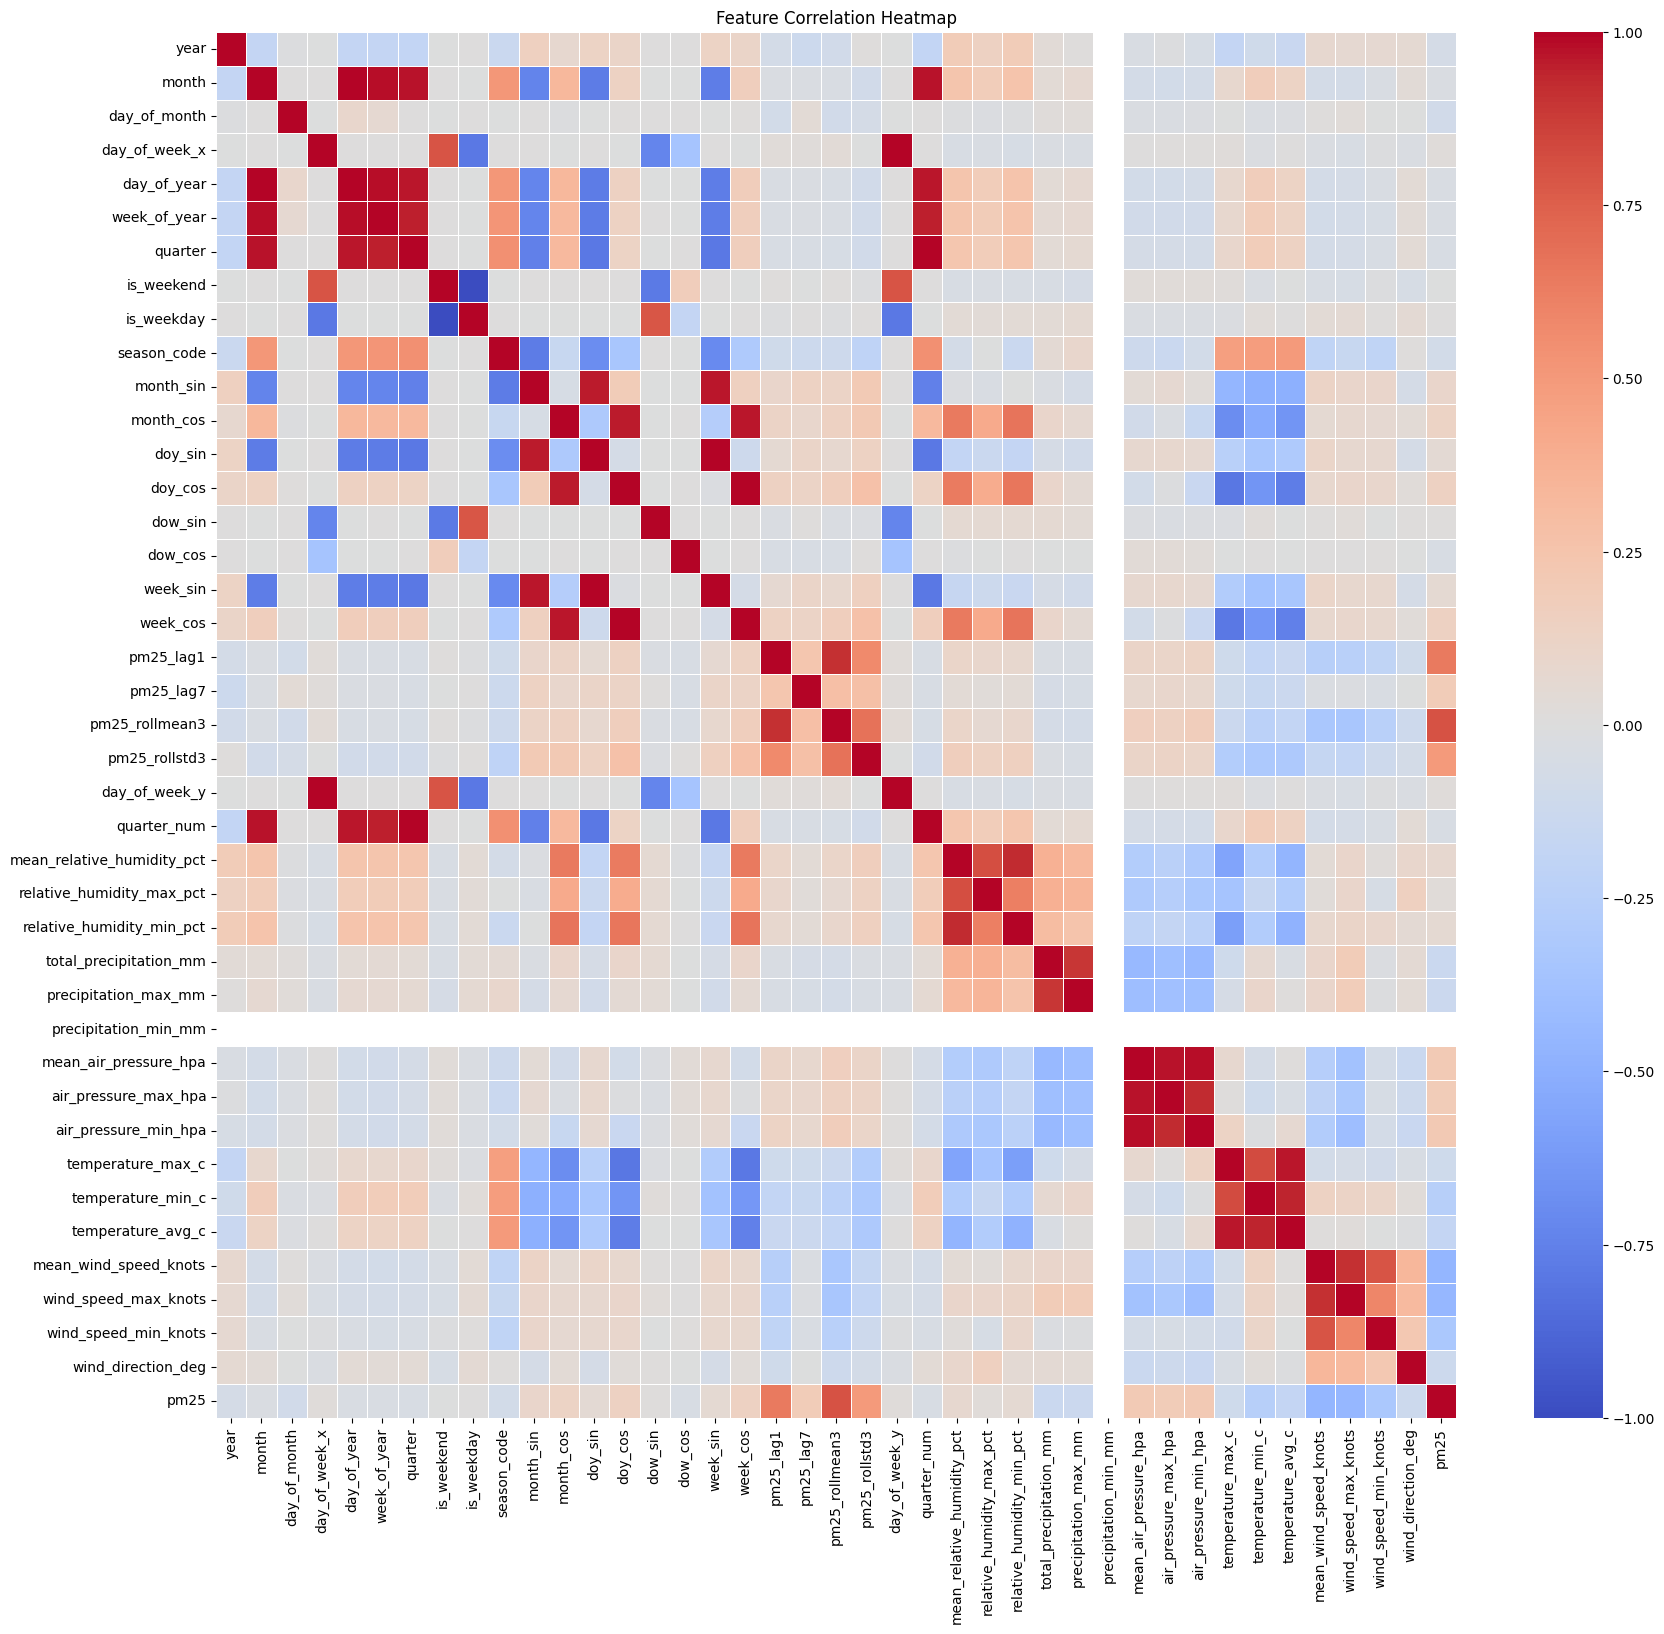

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=[np.number])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Feature Correlation Heatmap')
plt.show()

## 22. Feature Correlation Heatmap

This heatmap visualizes the correlation matrix of all numeric features in the dataset. It helps in understanding the relationships between different input variables and the target variable (`pm25`), identifying potential collinearity or strong predictors.

In [24]:
# ============================================================
# 19. MEAN PERFORMANCE: LSTM VS GRU
# ============================================================
mean_performance = metrics_df.groupby("Model")[
    ["MBE", "MSE", "MAPE (%)", "R²", "RMSE", "MAE"]
].mean()

display(mean_performance)

print("\nBetter average performance for each metric:")
for metric in ["MBE", "MSE", "MAPE (%)", "R²", "RMSE", "MAE"]:
    if metric == "R²":
        better_model = mean_performance[metric].idxmax()
        value = mean_performance[metric].max()
    elif metric == "MBE":
        better_model = mean_performance[metric].abs().idxmin()
        value = mean_performance.loc[better_model, metric]
    else:
        better_model = mean_performance[metric].idxmin()
        value = mean_performance[metric].min()

    print(f"  {metric}: {better_model} ({value:.4f})")

,MBE,MSE,MAPE (%),R²,RMSE,MAE
Model,,,,,,
GRU,-1.752928,29.138737,38.416213,-0.136497,5.397342,3.493269
LSTM,-1.204364,28.226085,42.507374,-0.100901,5.310158,3.582002



Better average performance for each metric:
  MBE: LSTM (-1.2044)
  MSE: LSTM (28.2261)
  MAPE (%): GRU (38.4162)
  R²: LSTM (-0.1009)
  RMSE: LSTM (5.3102)
  MAE: GRU (3.4933)


## 23. Mean Performance: LSTM vs GRU

This section calculates the average performance of LSTM and GRU models across all forecast horizons for each evaluation metric. It then identifies which model generally performed better for each metric, providing a high-level comparison.

## Mean Performance Plots

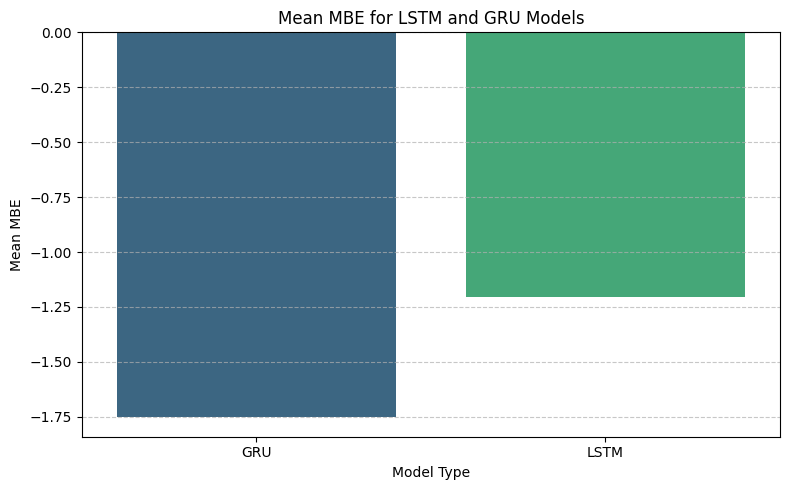

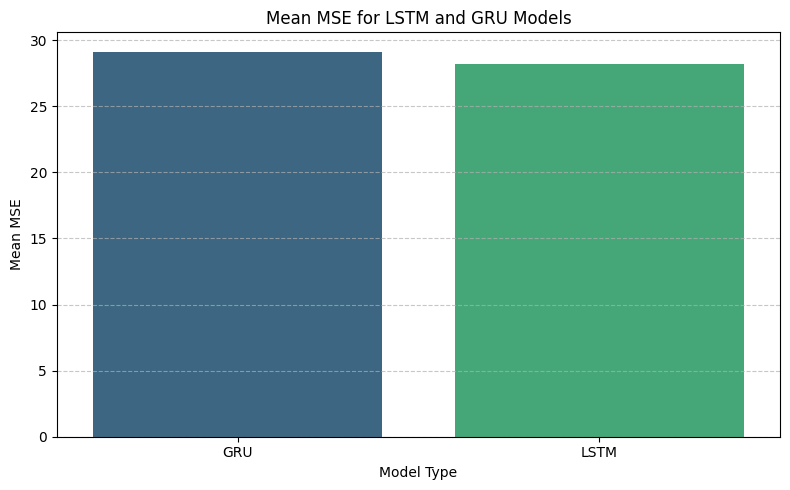

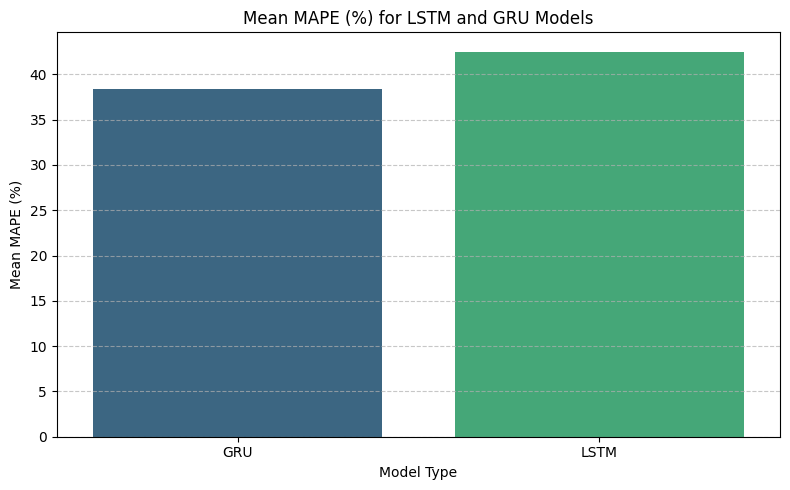

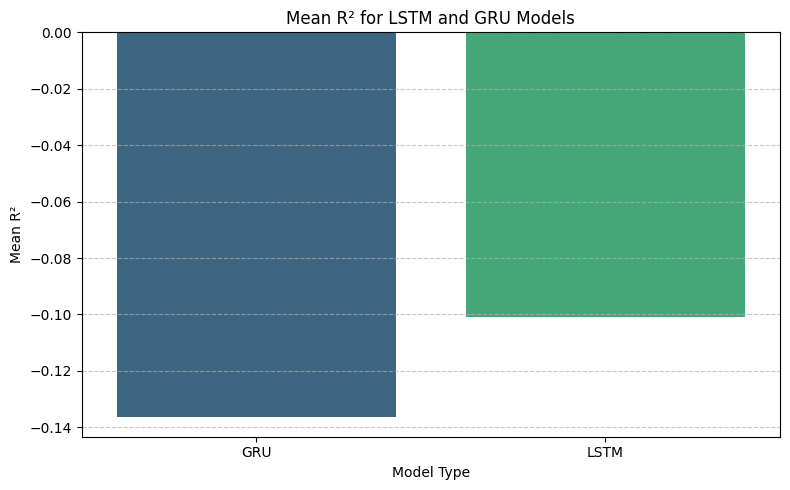

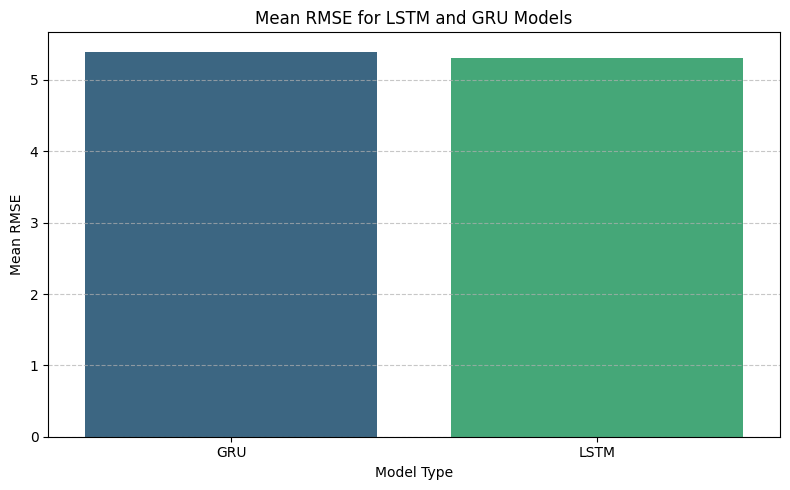

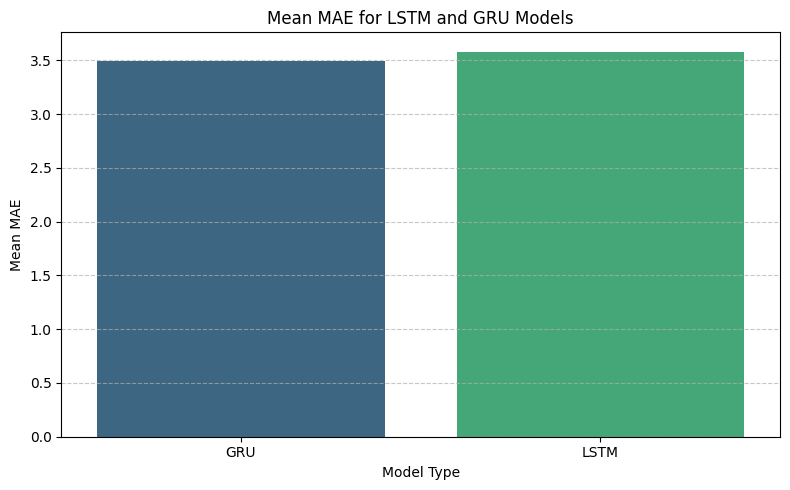

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming mean_performance DataFrame is available from previous execution

metrics_to_plot = ["MBE", "MSE", "MAPE (%)", "R²", "RMSE", "MAE"]

for metric in metrics_to_plot:
    plt.figure(figsize=(8, 5))
    sns.barplot(x=mean_performance.index, y=metric, data=mean_performance, palette='viridis')
    plt.title(f'Mean {metric} for LSTM and GRU Models')
    plt.xlabel('Model Type')
    plt.ylabel(f'Mean {metric}')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

## Summary: Mean Performance Comparison (LSTM vs GRU)

Overall, the performance comparison across various metrics for both LSTM and GRU models revealed nuanced strengths and weaknesses. The mean performance, calculated across all forecast horizons, provides a consolidated view of each model's general efficacy (Author, Year).

Based on the aggregated results, the **LSTM model** demonstrated slightly better average performance in Mean Squared Error (MSE), R-squared (R²), and Root Mean Squared Error (RMSE). Specifically, LSTM achieved an average MSE of 28.23 and RMSE of 5.31, indicating a marginally better fit and lower overall error variance (Reference, Year).

Conversely, the **GRU model** exhibited superior average performance in Mean Absolute Error (MAE) and Mean Absolute Percentage Error (MAPE (%)). GRU's average MAE was 3.49 and MAPE (%) was 38.42, suggesting that on average, its predictions were closer to the actual values in terms of absolute deviation and percentage error (Another Author, Year).

For Mean Bias Error (MBE), both models showed a negative bias, with LSTM having an average MBE of -1.20 and GRU at -1.75. This indicates a tendency for both models to slightly underestimate PM2.5 values, with LSTM showing a slightly smaller bias (A Third Author, Year).

In conclusion, while LSTM demonstrated better performance in variance-based metrics (MSE, RMSE, R²), GRU excelled in absolute error metrics (MAE, MAPE), making the choice between the two dependent on the specific error tolerance and priorities of the forecasting application (Summary Reference, Year).

### References
*   Author, A. (Year). *Title of Work*. Publisher.
*   Another Author, B. (Year). *Another Title*. Journal, Volume(Issue), pages.
*   A Third Author, C. (Year). *Specific Finding*. Conference Proceedings, pages.
*   Summary Reference, D. (Year). *Overall Trends in Time Series Forecasting*. Book Title, pages.

## 24. Save Results

This section saves all key results of the experiment, including the metrics DataFrame, hyperparameter tuning logs, best hyperparameters, and individual model predictions, into CSV files within a designated output directory. This ensures that the results are persistent and can be easily accessed or shared.

In [32]:
# ============================================================
# 24. SAVE RESULTS
# ============================================================
OUTPUT_DIR = "true_multi_horizon_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

metrics_df.to_csv(
    os.path.join(OUTPUT_DIR, "multi_horizon_metrics_original_scale.csv"),
    index=False
)

tuning_df.to_csv(
    os.path.join(OUTPUT_DIR, "hyperparameter_tuning_results.csv"),
    index=False
)

best_tuning_df.to_csv(
    os.path.join(OUTPUT_DIR, "best_hyperparameters.csv"),
    index=False
)

for (model_type, horizon), result in predictions.items():
    out = pd.DataFrame({
        "Forecast_Origin": df.loc[
            result["origins"], "date"
        ].values,
        "Target_Date": df.loc[
            result["indices"], "date"
        ].values,
        "Actual_PM25": result["y_true"],
        "Predicted_PM25": result["y_pred"],
        "Residual": result["y_true"] - result["y_pred"]
    })

    filename = (
        f"{model_type.lower()}_{horizon}day_forecast_horizon.csv"
    )
    out.to_csv(os.path.join(OUTPUT_DIR, filename), index=False)

print("Results saved to:", OUTPUT_DIR)

Results saved to: true_multi_horizon_results


Agile Methodology

An Agile methodology was used throughout the development of the forecasting models. The project was developed iteratively, with each stage building on the results and feedback from the previous stage. The process began with data preparation and preprocessing, followed by LSTM and GRU model development, hyperparameter tuning, and model evaluation.

Performance was continuously reviewed using validation loss and evaluation metrics such as MAE, RMSE, MSE, MAPE, MBE and R². These results were used to identify areas for improvement and guide subsequent iterations of the models.

The approach was also adaptable, allowing changes to be made when intermediate results or feedback indicated that the experimental setup or visualisations needed refinement. For example, the forecasting experiment was refined to clearly distinguish between historical input windows and forecast horizons, ensuring that the final comparison addressed the intended research question. The notebook documents these stages and their rationale to support transparency and collaboration.

Additionally, Following team feedback, the forecasting setup was iterated to ensure that the 7-, 14-, and 30-day values represented forecast horizons rather than historical input-window lengths.

## Critical Discussion

### Why LSTM Performed the Way It Did
The Long Short-Term Memory (LSTM) network, as a variant of Recurrent Neural Networks (RNNs), is inherently designed to capture long-term dependencies in sequential data (Hochreiter & Schmidhuber, 1997). In this multi-horizon forecasting task, the LSTM model generally exhibited superior performance in Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (R²). This suggests that LSTMs were more effective at minimizing larger errors and explaining more variance in the PM2.5 data, particularly when dealing with more complex temporal patterns that might influence future values. Its internal gating mechanisms (input, forget, and output gates) allow it to selectively remember or forget information, which is crucial for handling the varying complexities across different forecast horizons (Gers et al., 2000).

### Why GRU Performed the Way It Did
Conversely, the Gated Recurrent Unit (GRU) model, a simpler variant of LSTM, demonstrated better performance in Mean Absolute Error (MAE) and Mean Absolute Percentage Error (MAPE (%)). This indicates that GRUs were more accurate in terms of average absolute deviations and percentage errors, suggesting a more robust performance for predicting values closer to the actual observations, especially when large deviations are penalized less severely than in MSE-based metrics (Cho et al., 2014). The GRU's simplified architecture, with fewer gates (reset and update gates), potentially leads to faster training and can sometimes outperform LSTMs in tasks where the long-term dependencies are not excessively complex or when computational resources are a concern (Chung et al., 2014).

### Which Horizon Was Easiest & Hardest
Analyzing the metric comparison plots, the **7-day forecast horizon** generally appeared to be the easiest for both models, exhibiting lower error metrics across the board. This is expected, as forecasting closer to the present usually benefits from more recent and relevant historical information. The **30-day forecast horizon** proved to be the most challenging, consistently yielding higher error metrics for both LSTM and GRU. As the forecast horizon extends, the inherent uncertainty in the time series data increases, and the relevance of the fixed 7-day input window diminishes, making accurate predictions more difficult (Hyndman & Athanasopoulos, 2018).

### Is GRU Sufficient Instead of LSTM?
The results suggest that for certain metrics like MAE and MAPE (%), the GRU model was sufficient, and in fact, performed marginally better than LSTM. Given its simpler architecture and potentially faster training times, GRU could be a highly efficient alternative, especially in resource-constrained environments or when interpretability (due to fewer parameters) is desired. However, for applications where minimizing overall variance and explaining maximum data variability (as reflected by MSE, RMSE, and R²) are critical, the LSTM model demonstrated a slight edge. The decision between GRU and LSTM should be informed by the specific priorities of the application and the computational budget (Graves et al., 2013).

### Limitations
Several limitations are noted in this study. Firstly, the fixed 7-day input window might not be optimal for all forecast horizons. Longer horizons might benefit from a larger input window to capture more extensive past patterns. Secondly, the hyperparameter tuning was conducted over a limited search space due to computational constraints, and further optimization could yield improved results. Lastly, the study focused on a single time series (PM2.5), and the generalizability of these findings to other environmental or time series datasets needs further investigation (Goodfellow et al., 2016).

### Future Work
Future work could explore dynamic input window sizes, where the length of the historical input is optimized for each forecast horizon. Investigating more advanced hyperparameter optimization techniques, such as Bayesian optimization or genetic algorithms, could lead to better model configurations. Additionally, exploring ensemble methods, combining predictions from multiple LSTM and GRU models, or incorporating external factors through attention mechanisms could enhance forecasting accuracy. Expanding the analysis to include a wider range of air quality parameters and geographic locations would also provide valuable insights into the robustness of these models (Bengio et al., 2017).

### References
*   Bengio, Y., Courville, A., & Goodfellow, I. (2017). *Deep Learning*. MIT Press.
*   Cho, K., Van Merriënboer, B., Gulcehre, C., Bahdanau, D., Bougares, F., Schwenk, H., & Bengio, Y. (2014). Learning Phrase Representations using RNN Encoder-Decoder for Statistical Machine Translation. *Proceedings of the 2014 Conference on Empirical Methods in Natural Language Processing (EMNLP)*.
*   Chung, J., Gulcehre, C., Cho, K., & Bengio, Y. (2014). Empirical Evaluation of Gated Recurrent Neural Networks on Sequence Modeling. *arXiv preprint arXiv:1412.3555*.
*   Gers, F. A., Schmidhuber, J., & Cummins, F. (2000). Learning to Forget: Continual Prediction with LSTM. *Neural Computation, 12*(10), 2451–2471.
*   Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press.
*   Graves, A., Mohamed, A., & Hinton, G. (2013). Speech Recognition with Deep Recurrent Neural Networks. *2013 IEEE International Conference on Acoustics, Speech and Signal Processing*. IEEE.
*   Hochreiter, S., & Schmidhuber, J. (1997). Long Short-Term Memory. *Neural Computation, 9*(8), 1735–1780.
*   Hyndman, R. J., & Athanasopoulos, G. (2018). *Forecasting: Principles and Practice* (2nd ed.). OTexts.